In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
from pathlib import Path
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import linregress
import pymannkendall as mk

plt.rcParams["figure.dpi"] = 300

In [2]:
# Set plotting defaults (keeps matplotlib default colors unless user changes)
plt.rcParams['figure.dpi'] = 300

In [3]:
DATA_PATH = '/mnt/data/Cpds with IC50_Chembl-Numbered.csv' 
SHEET = None # if CSV is used
OUTDIR = Path('/mnt/data/outputs_publication1')
OUTDIR.mkdir(parents=True, exist_ok=True)
TOP_K_TARGETS = 8
ACTIVE_THRESH_NM = 1000.0 # IC50 threshold for "active" (nM)
BOOTSTRAP_RESAMPLES = 2000

In [4]:
df  = pd.read_csv('Cpds with IC50_Chembl-Numbered.csv')

In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (11495, 44)


In [6]:
# Harmonize column names
col_map = {
'Molecular Weight': 'MW',
'#RO5 Violations': 'RO5_violations',
'Standard Value': 'IC50',
'Document Year': 'Year',
}
for k,v in col_map.items():
    if k in df.columns:
        df = df.rename(columns={k:v})

In [7]:
# Filter to IC50 records (if Standard Type exists)
if 'Standard Type' in df.columns:
    df = df[df['Standard Type'].astype(str).str.upper() == 'IC50'].copy()

In [8]:
# Keep numeric, positive IC50
df = df[pd.notnull(df.get('IC50')) & (df['IC50'] > 0)].copy()

In [9]:
# Ensure numeric columns exist
for numeric_col in ['RO5_violations','MW','AlogP','Year']:
    if numeric_col in df.columns:
        df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

In [10]:
# Year: drop missing years only when needed for time-series
# Compute log10(IC50)
df['pIC50'] = np.log10(df['IC50'])
# Active flag
df['is_active'] = (df['IC50'] <= ACTIVE_THRESH_NM).astype(int)


print('Clean rows (IC50>0):', len(df))

Clean rows (IC50>0): 11322


In [11]:
# Save cleaned snapshot
df.to_csv(OUTDIR / 'cleaned_ic50_publication1.csv', index=False)

In [12]:
# Time-series analysis: yearly aggregates and bootstrap CIs for median


# Prepare years column if available
if 'Year' in df.columns:
    df_year = df.dropna(subset=['Year']).copy()
    df_year['Year'] = df_year['Year'].astype(int)
else:
    df_year = pd.DataFrame()

In [13]:
# Yearly aggregates: N, median, mean, IQR, % active
if not df_year.empty:
    def q1(x): return np.percentile(x,25)
    def q3(x): return np.percentile(x,75)


    yearly = df_year.groupby('Year').agg(
        N=('IC50','size'),
        median_log10IC50=('pIC50','median'),
        mean_log10IC50=('pIC50','mean'),
        q1_log10=('pIC50', q1),
        q3_log10=('pIC50', q3),
        pct_active=('is_active','mean')
    ).reset_index().sort_values('Year')
    yearly['pct_active'] = (yearly['pct_active']*100).round(2)
    yearly['IQR_log10IC50'] = yearly['q3_log10'] - yearly['q1_log10']

In [14]:
# Bootstrap median CIs (basic) for years with n>=5
from numpy.random import default_rng
rng = default_rng()
ci_low = []
ci_high = []
for _, row in yearly.iterrows():
    vals = df_year.loc[df_year['Year']==int(row['Year']), 'pIC50'].dropna().values
    if len(vals) >= 5:
        medians = []
        for _ in range(BOOTSTRAP_RESAMPLES):
            sample = rng.choice(vals, size=len(vals), replace=True)
            medians.append(np.median(sample))
        lo = np.percentile(medians, 2.5)
        hi = np.percentile(medians, 97.5)
    else:
        lo, hi = np.nan, np.nan
    ci_low.append(lo)
    ci_high.append(hi)
yearly['ci_low'] = ci_low
yearly['ci_high'] = ci_high


yearly.to_csv(OUTDIR / 'yearly_trends_publication1.csv', index=False)

In [15]:
#Linear Regression Trend

slope, intercept, r, p, stderr = linregress(
    yearly["Year"], yearly["median_log10IC50"]
)

print(f"Slope: {slope:.4f}")
print(f"R²: {r**2:.3f}")
print(f"P-value: {p:.3e}")

Slope: 0.0174
R²: 0.038
P-value: 3.209e-01


In [16]:
#Mann–Kendall Trend Test

mk_result = mk.original_test(yearly["median_log10IC50"])

mk_result

Mann_Kendall_Test(trend='no trend', h=False, p=0.9055732240996304, z=-0.11862403313740862, Tau=-0.018518518518518517, s=-7.0, var_s=2558.3333333333335, slope=-0.003962058027803537, intercept=3.4641266075507824)

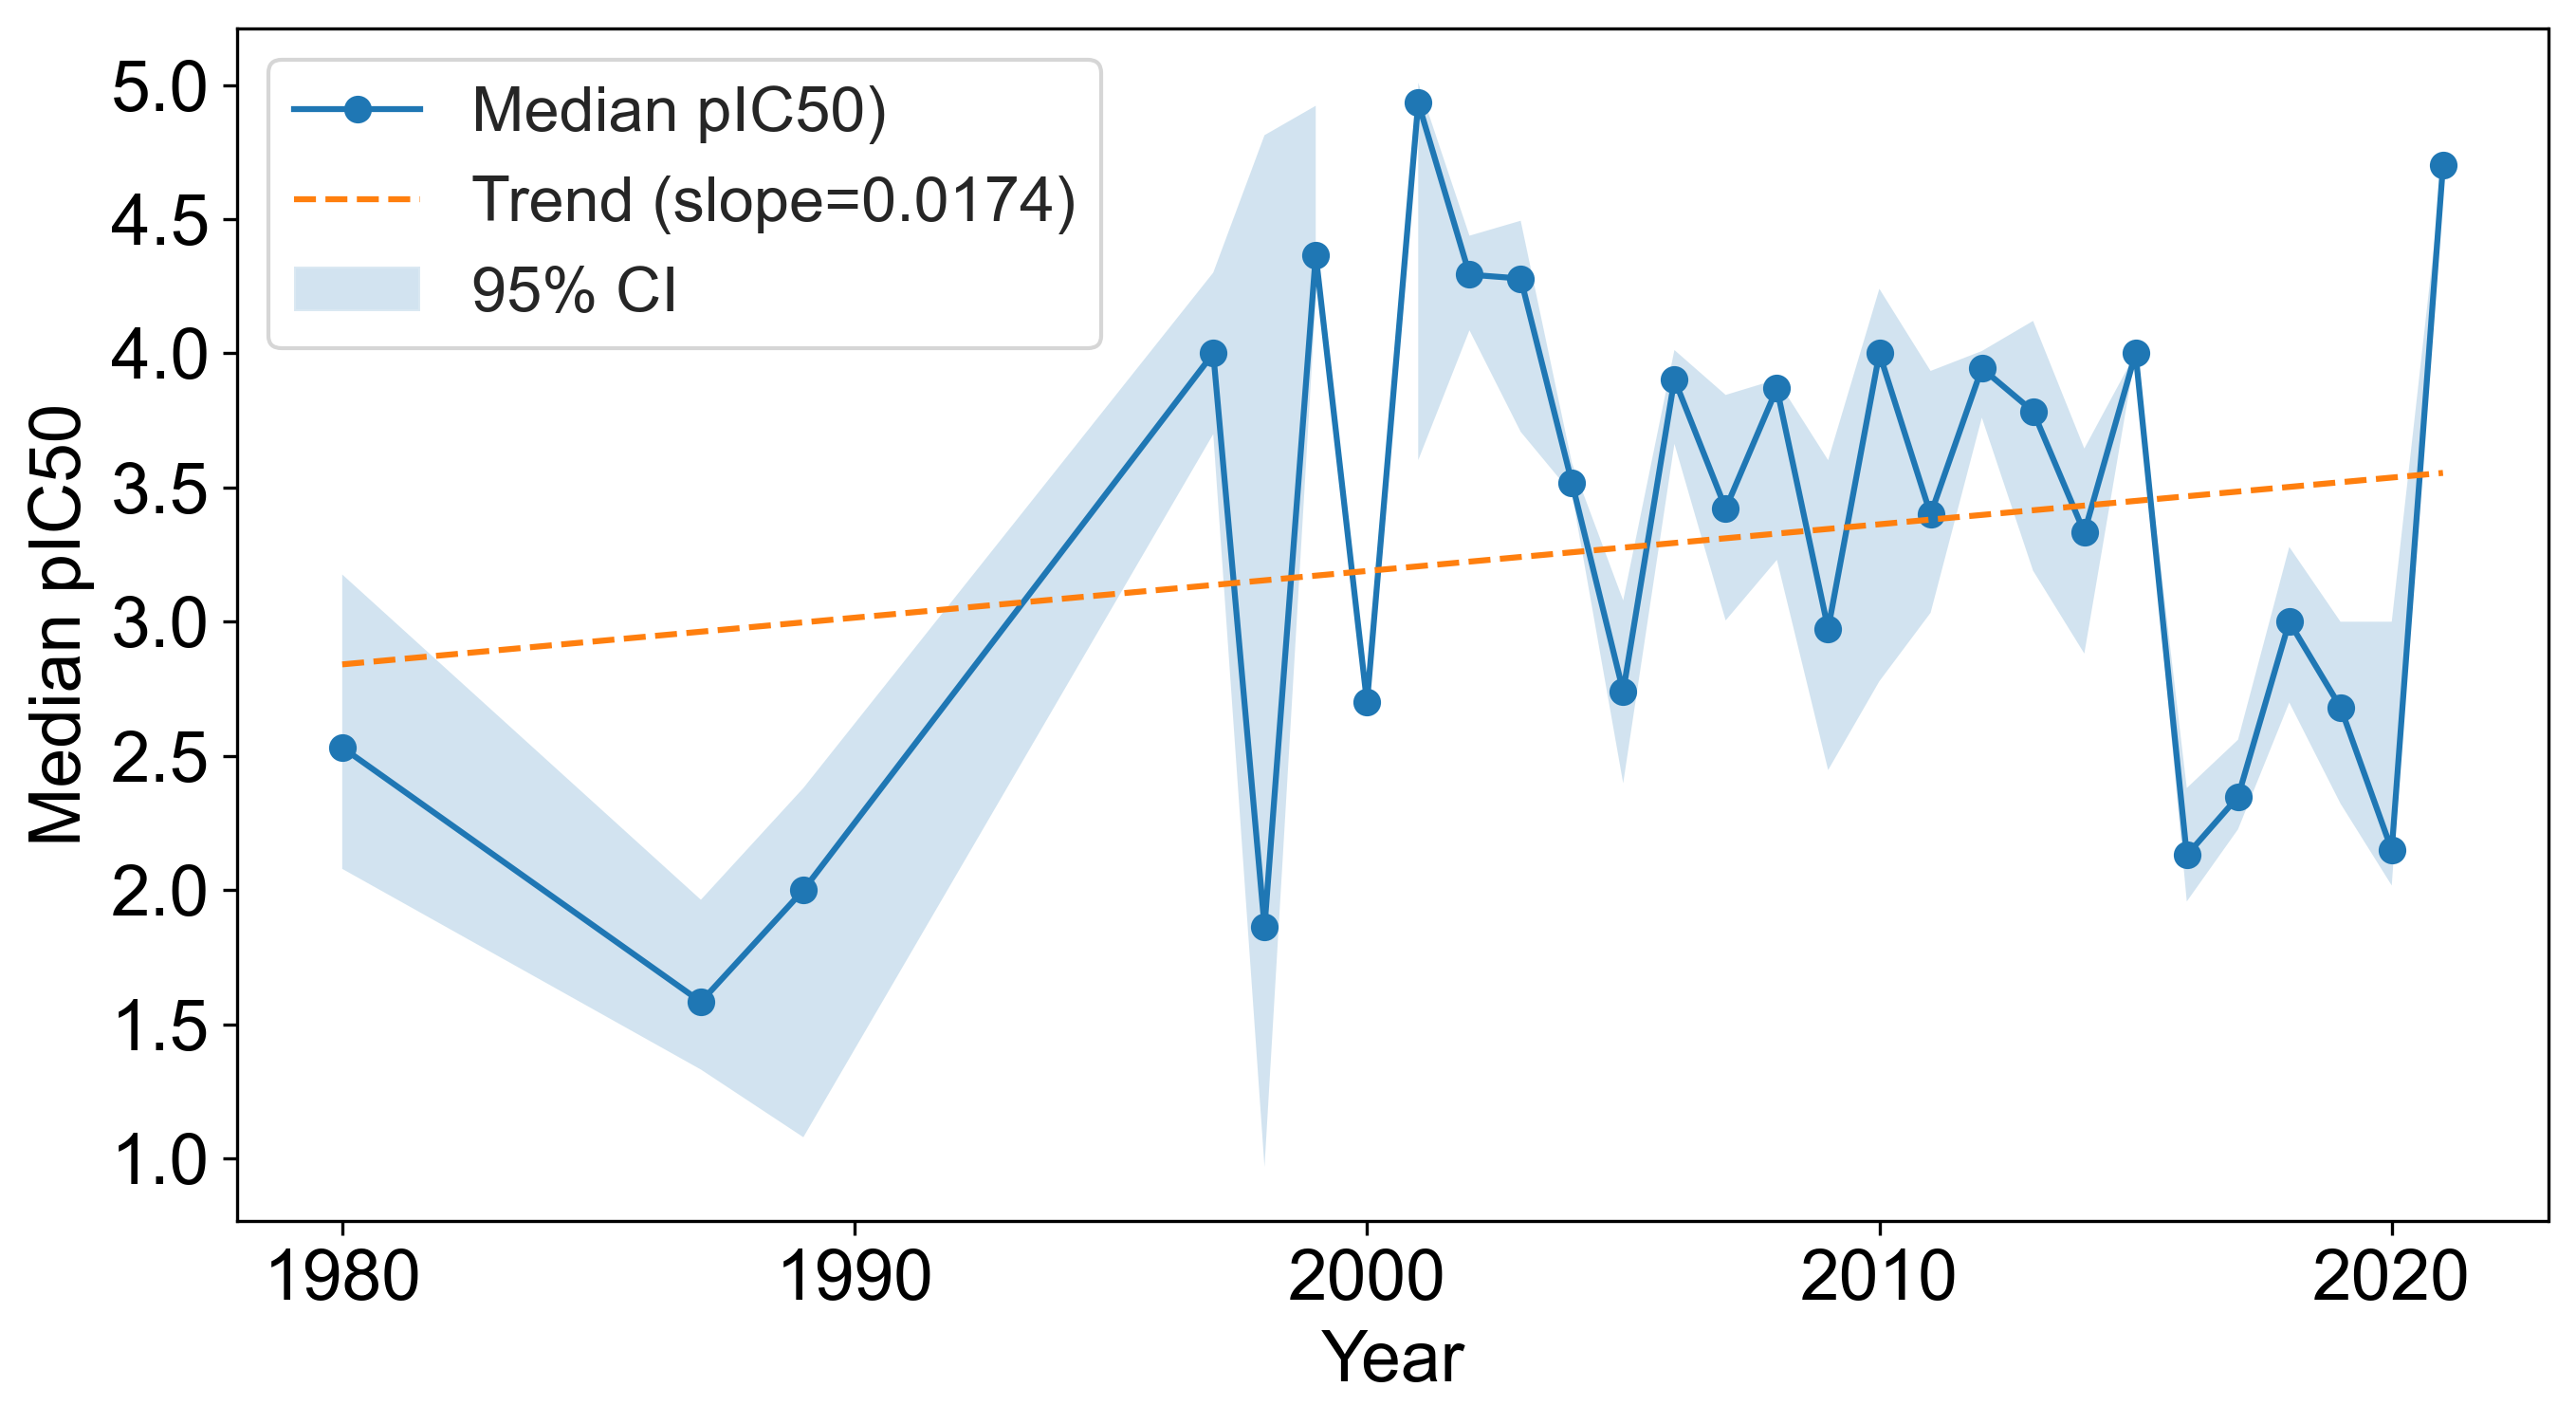

In [18]:
# Time-series figures 

if not df_year.empty:
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(yearly['Year'], yearly['median_log10IC50'], marker='o', label='Median pIC50)')
    # CI band
    ax.fill_between(yearly['Year'], yearly['ci_low'], yearly['ci_high'], alpha=0.2, label='95% CI')
    # Linear fit
    mask = yearly['median_log10IC50'].notna()
    if mask.sum() >= 2:
        z = np.polyfit(yearly['Year'][mask], yearly['median_log10IC50'][mask], 1)
        p = np.poly1d(z)
    sns.set_style("whitegrid")
    ax.plot(yearly['Year'], p(yearly['Year']), '--', label=f'Trend (slope={z[0]:.4f})')
    #ax.set_title('Median log10(IC50) Over Time')
    ax.set_xlabel('Year', fontsize = 18)
    ax.set_ylabel('Median pIC50', fontsize =18)
    ax.legend(fontsize =16)
    plt.tight_layout()
    plt.xticks(fontsize=18, fontname='Arial')   
    plt.yticks(fontsize=18, fontname='Arial')
    fig.savefig(OUTDIR / 'figure_median_log10IC50_trend.png', dpi=300)
    plt.show()

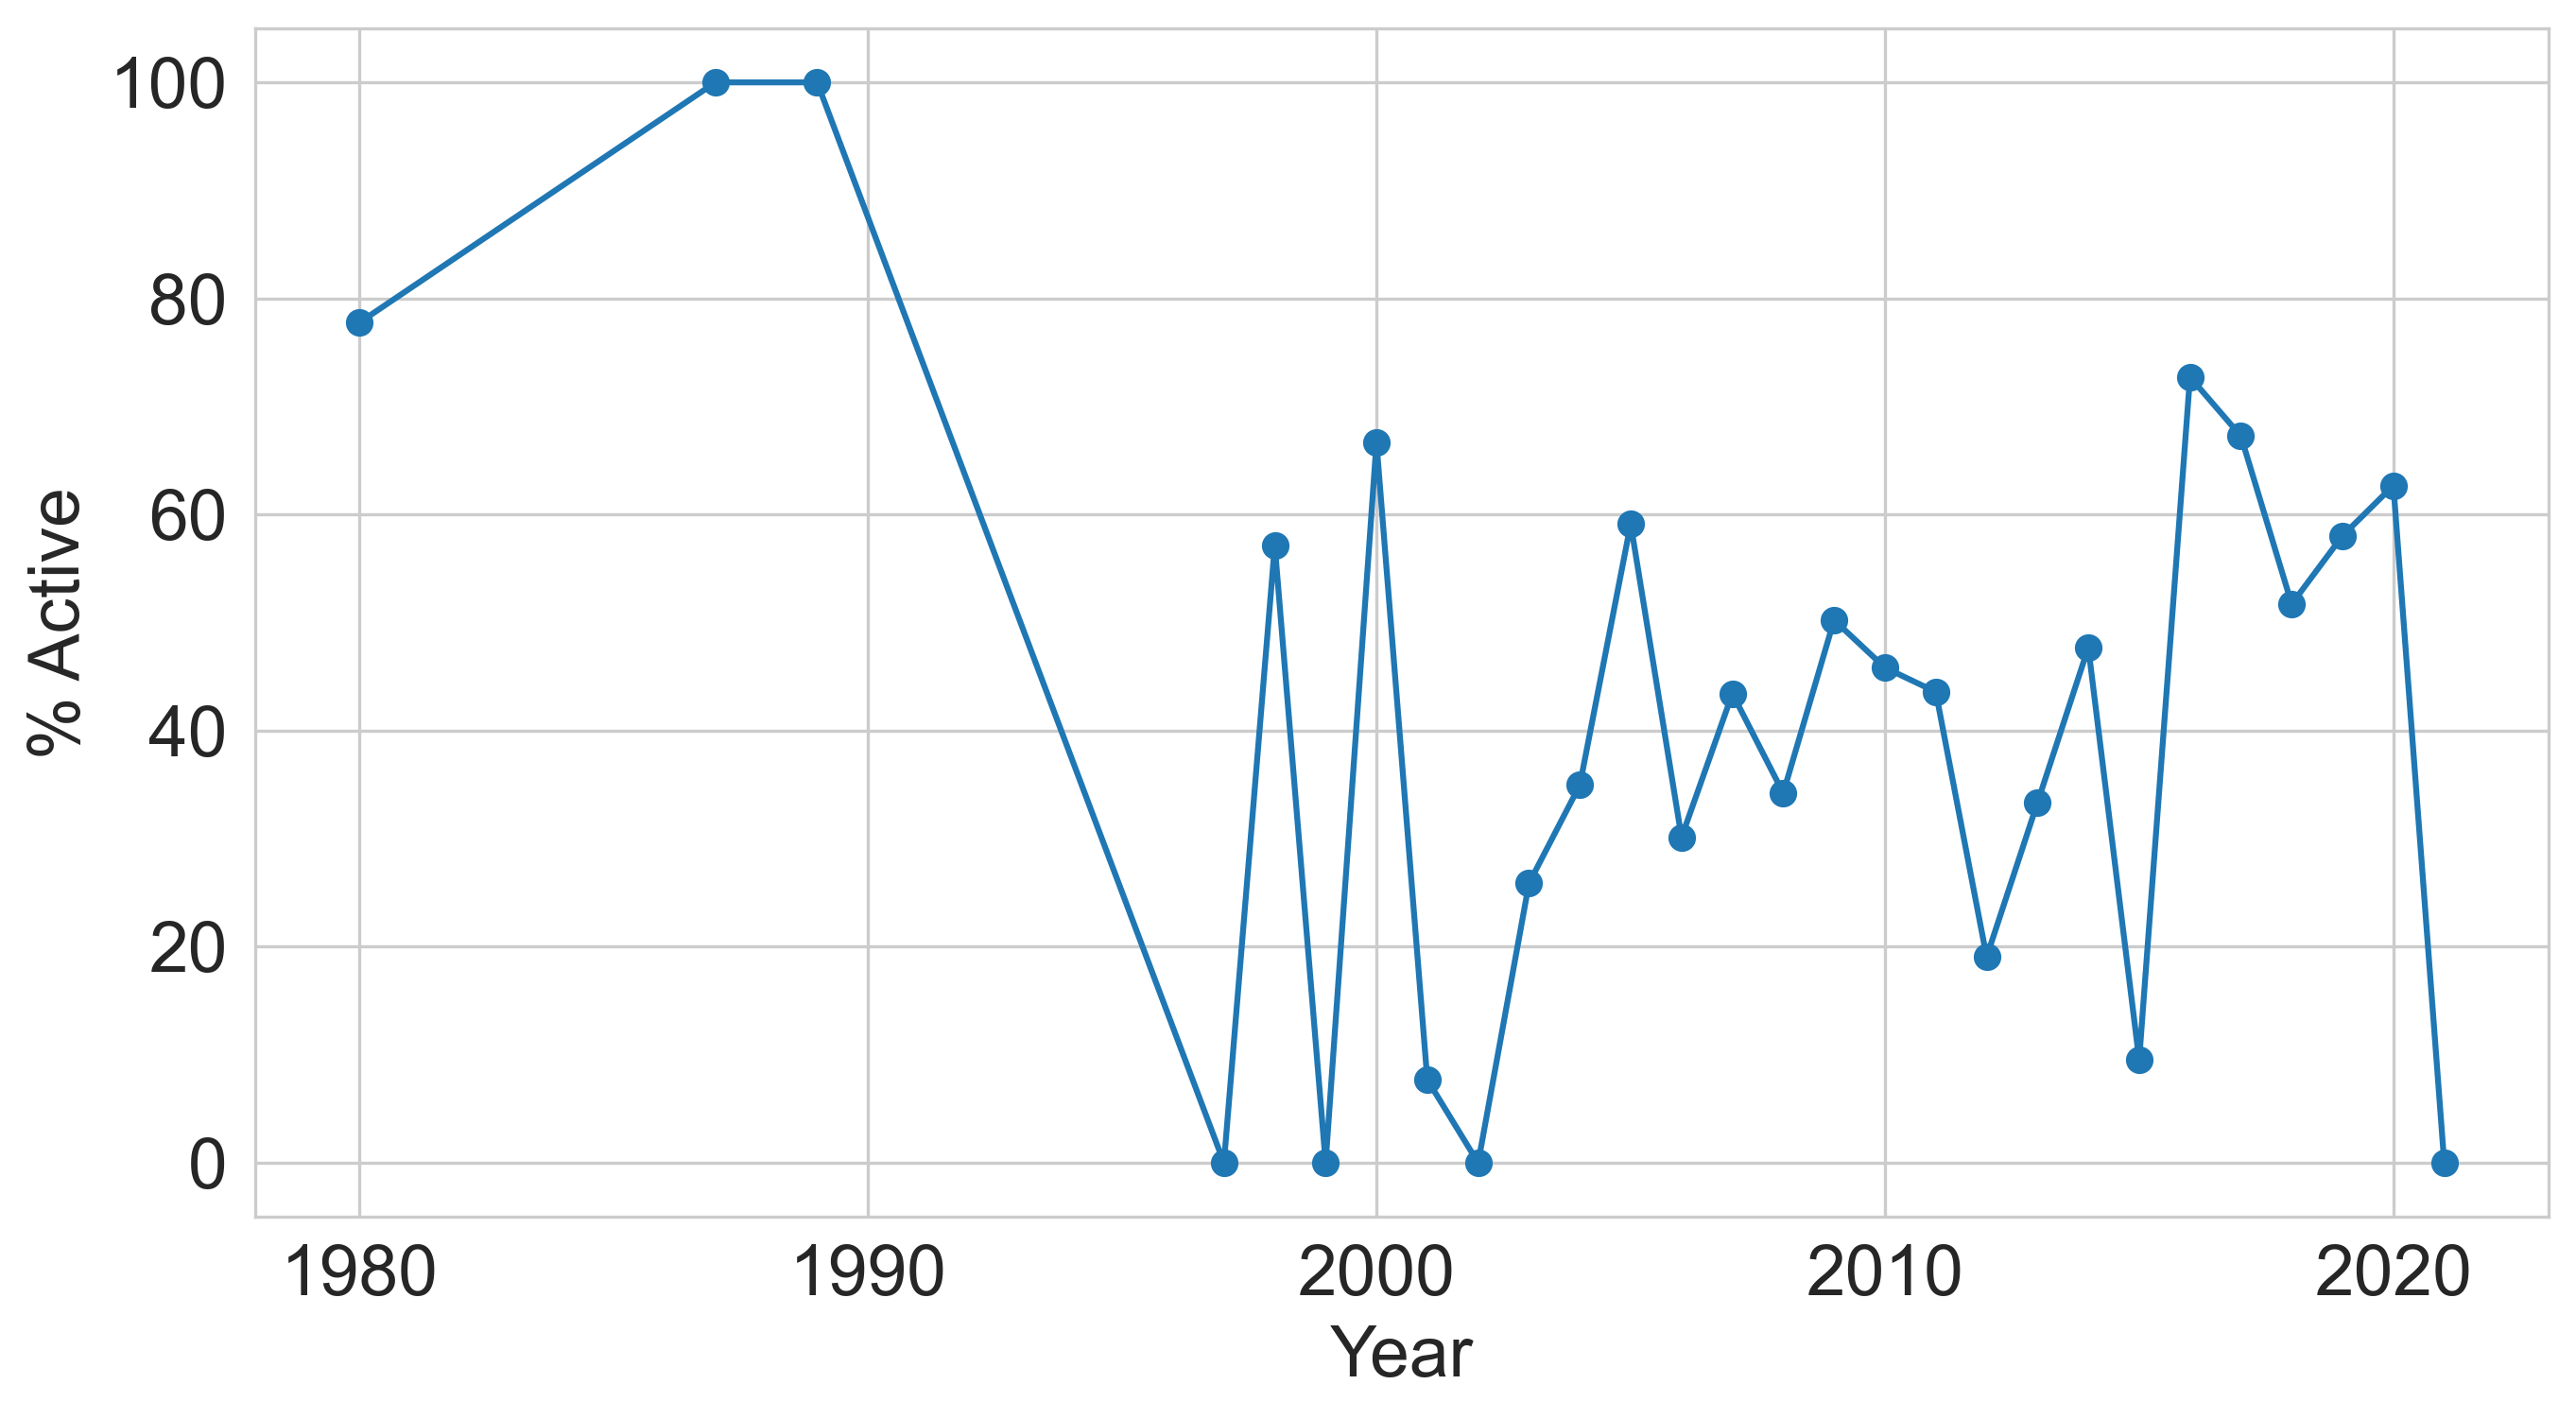

In [19]:
# Percent active over time
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(yearly['Year'], yearly['pct_active'], marker='o')
#ax.set_title('Percent Active Compounds (IC50 ≤ 1000 nM) Over Time')
ax.set_xlabel('Year', fontsize =18)
ax.set_ylabel('% Active', fontsize =18)
plt.tight_layout()
plt.xticks(fontsize=18, fontname='Arial')   
plt.yticks(fontsize=18, fontname='Arial')
fig.savefig(OUTDIR / 'figure_pct_active_trend.png', dpi=300)
plt.show()

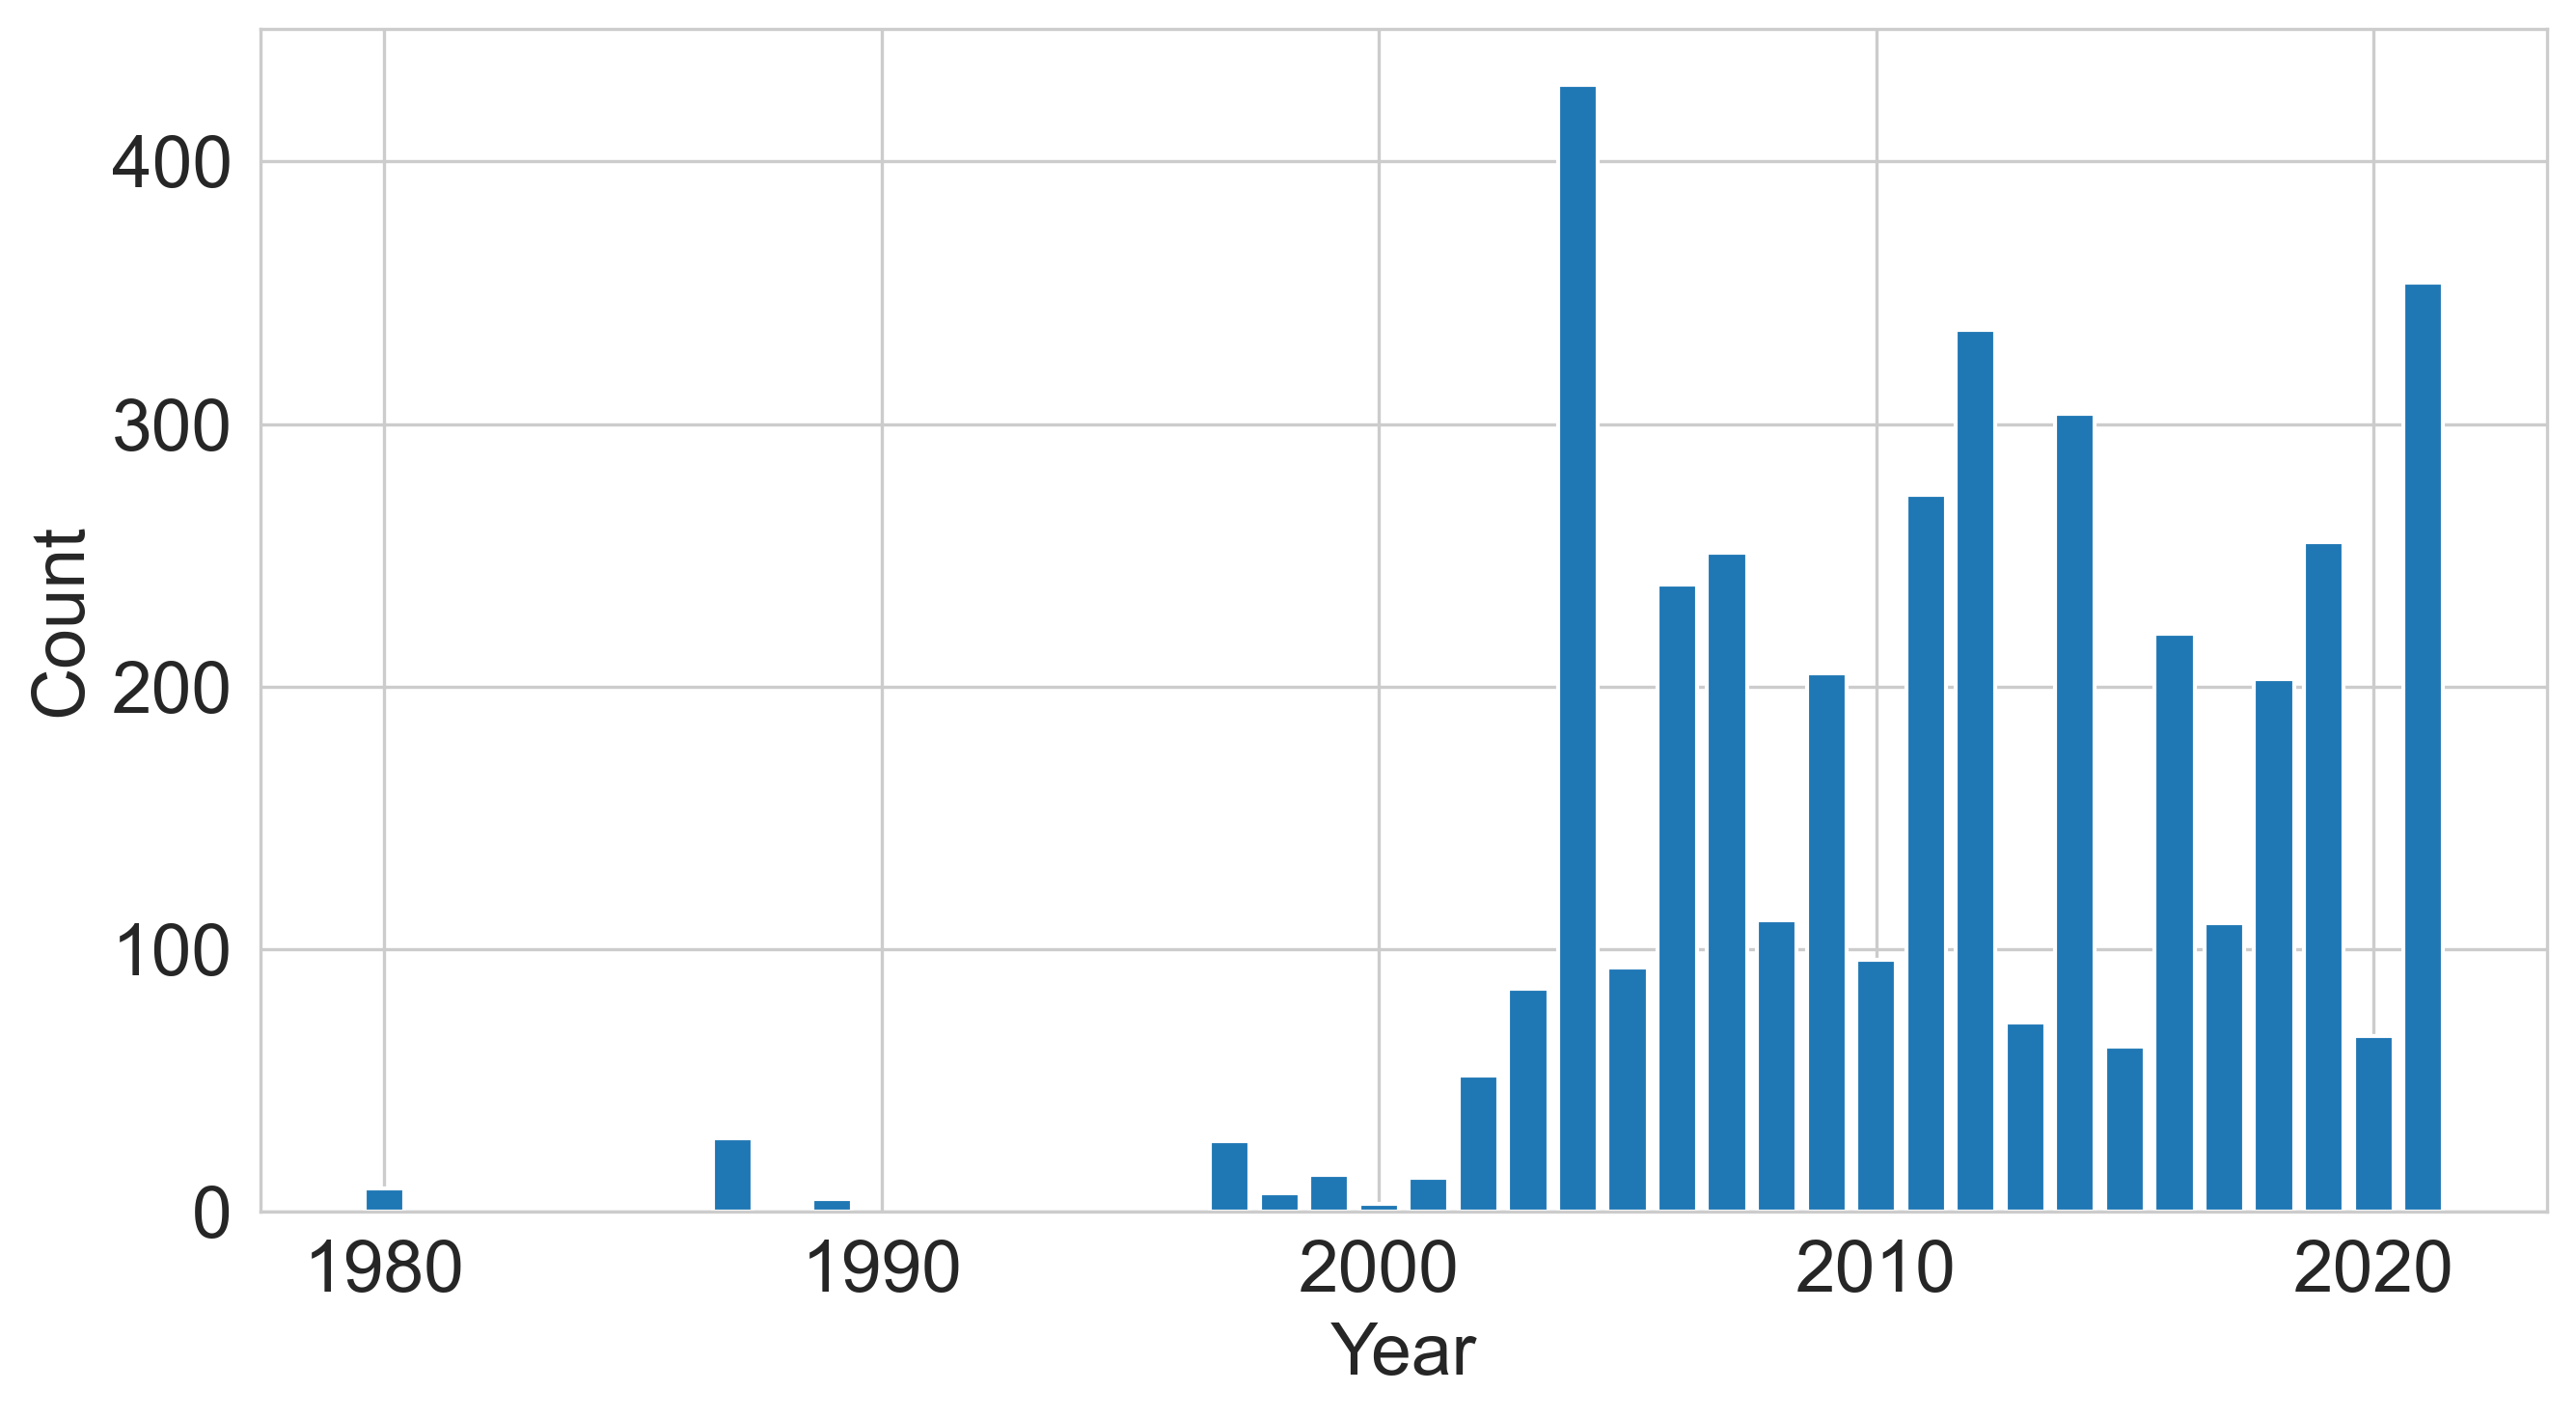

In [20]:
# Counts per year
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(yearly['Year'], yearly['N'])
#ax.set_title('Number of IC50 Records Per Year')
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
plt.xticks(fontsize=18, fontname='Arial')   
plt.yticks(fontsize=18, fontname='Arial')
plt.tight_layout()
fig.savefig(OUTDIR / 'figure_counts_per_year.png', dpi=300)
plt.show()

In [21]:
# Target-specific potency profiling
# Aggregate potency metrics per reported Target Name and save top-K summaries and plots.

# Ensure Target Name exists
if 'Target Name' not in df.columns:
    df['Target Name'] = 'Unknown'


agg_target = df.groupby('Target Name').agg(
    records=('IC50','size'),
    median_IC50=('IC50','median'),
    median_log10IC50=('pIC50','median'),
    mean_log10IC50=('pIC50','mean'),
    q1_log10=('pIC50', lambda x: np.percentile(x,25)),
    q3_log10=('pIC50', lambda x: np.percentile(x,75))
).reset_index()
agg_target['IQR_pIC50'] = agg_target['q3_log10'] - agg_target['q1_log10']
agg_target = agg_target.sort_values('records', ascending=False)
agg_target.to_csv(OUTDIR / 'target_level_summary_publication1.csv', index=False)


# Top K targets
top_targets = agg_target.head(TOP_K_TARGETS).copy()
top_targets.to_csv(OUTDIR / 'top_targets_publication1.csv', index=False)

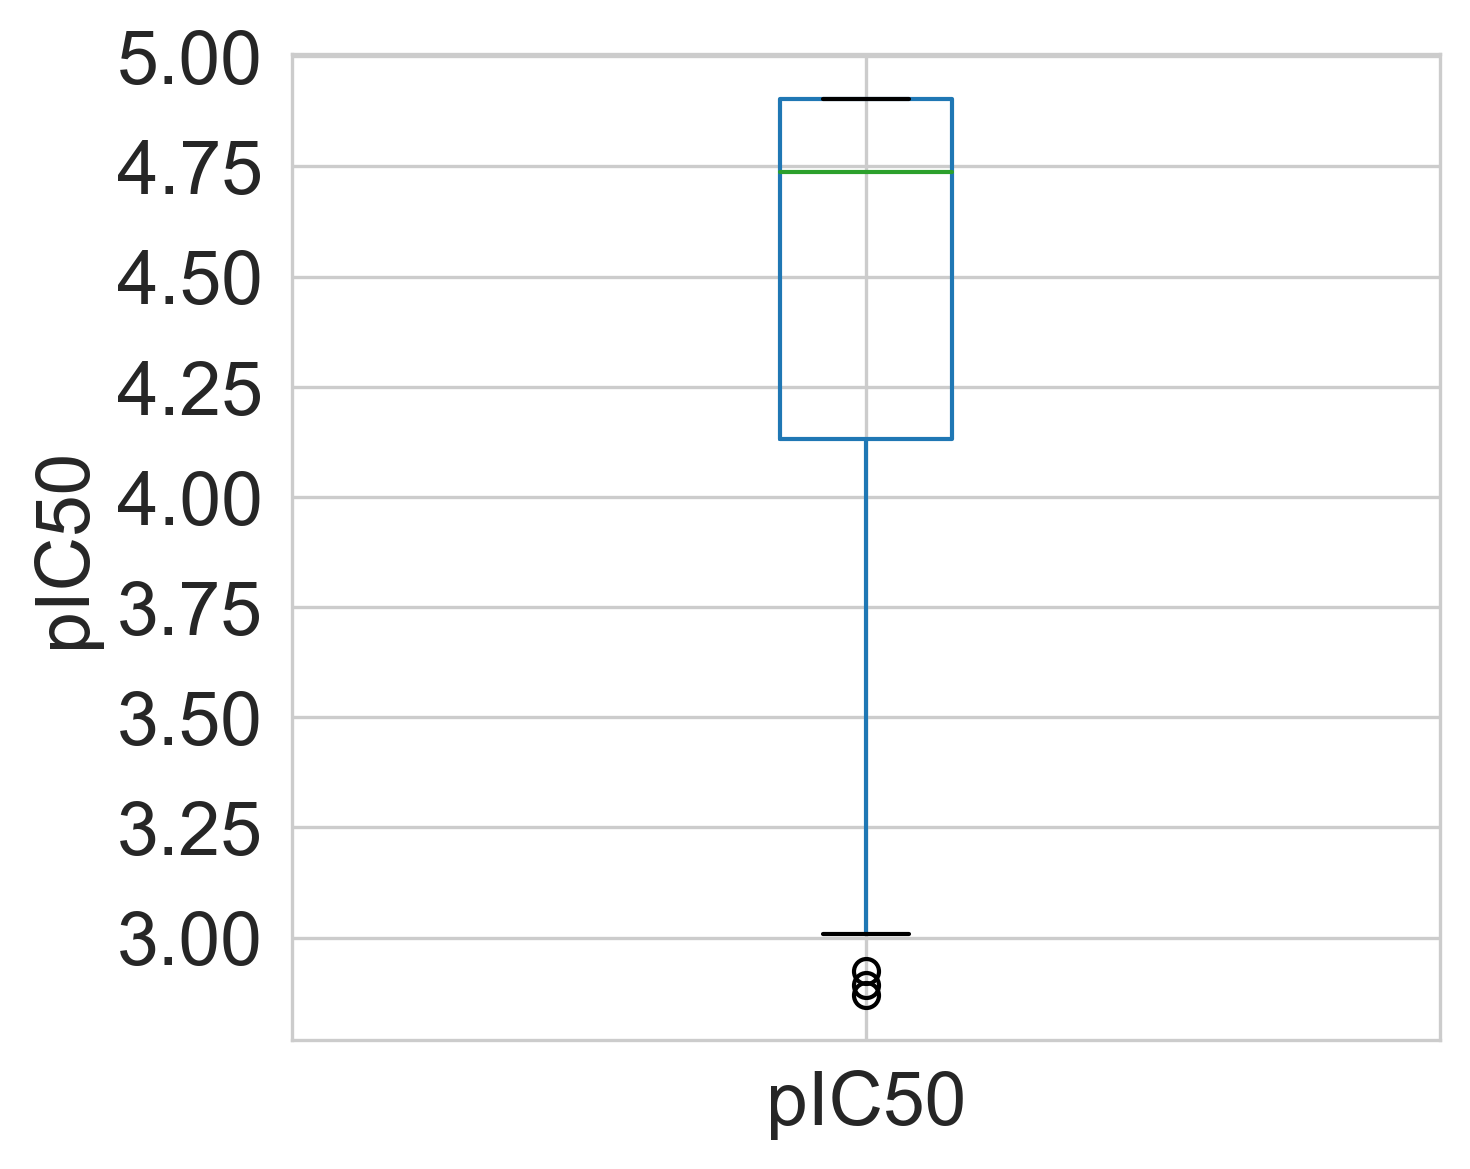

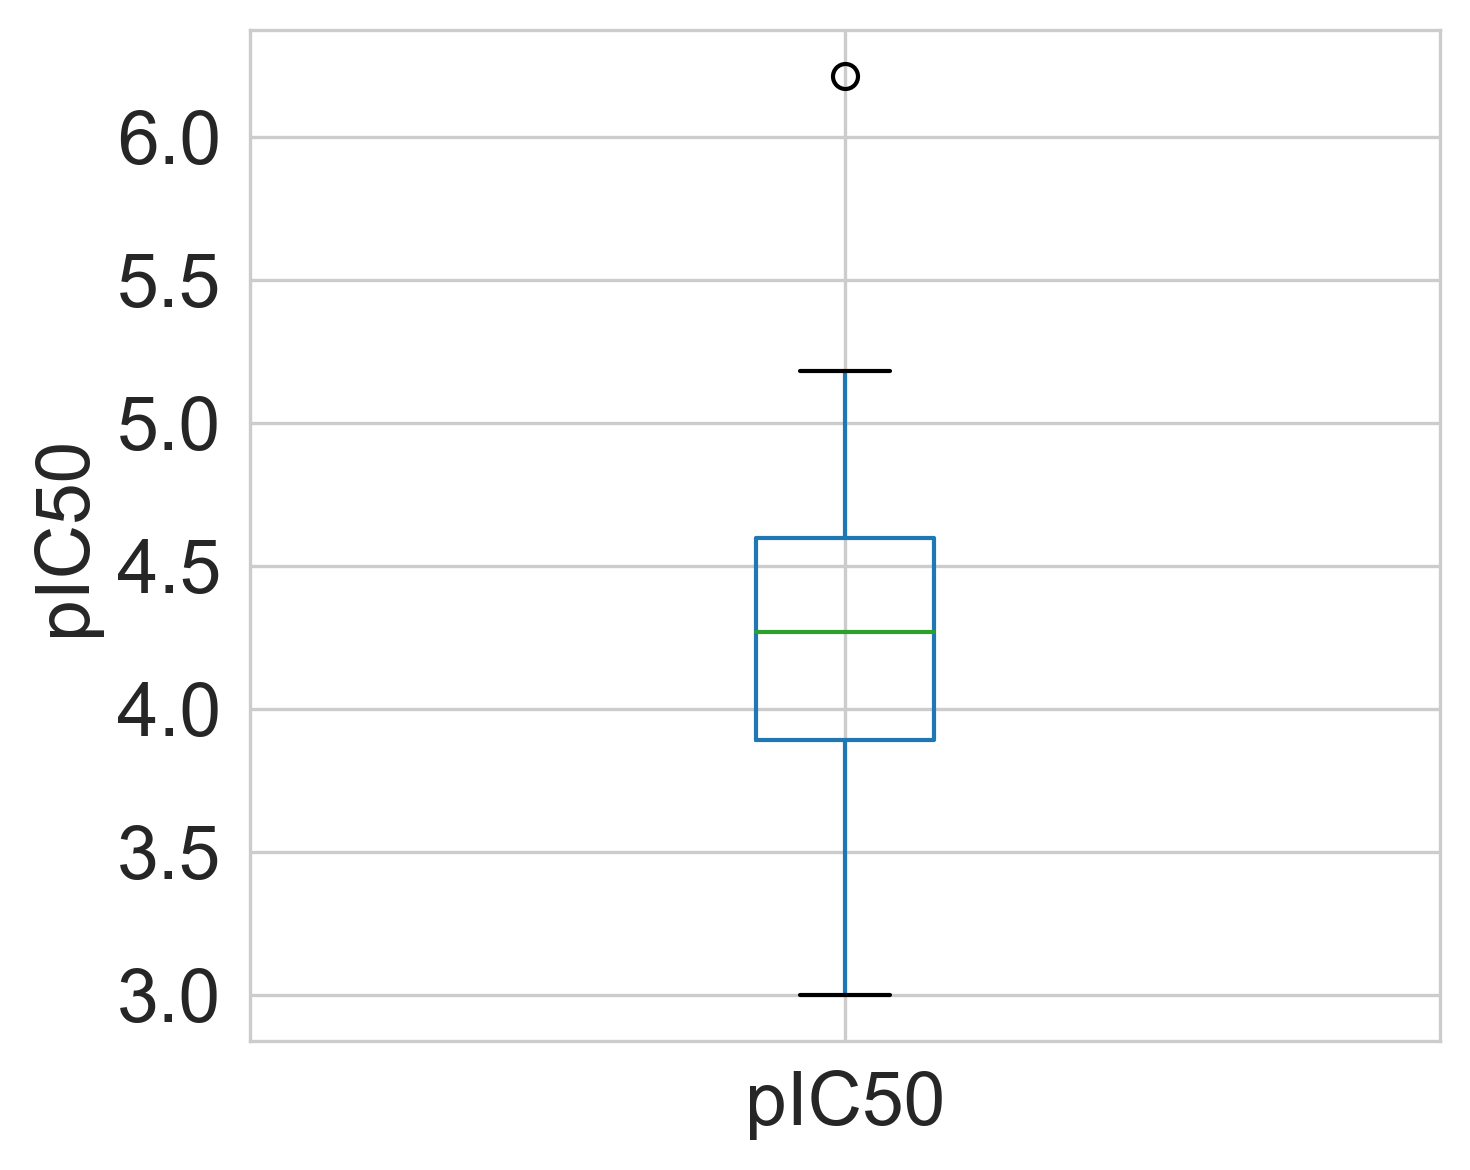

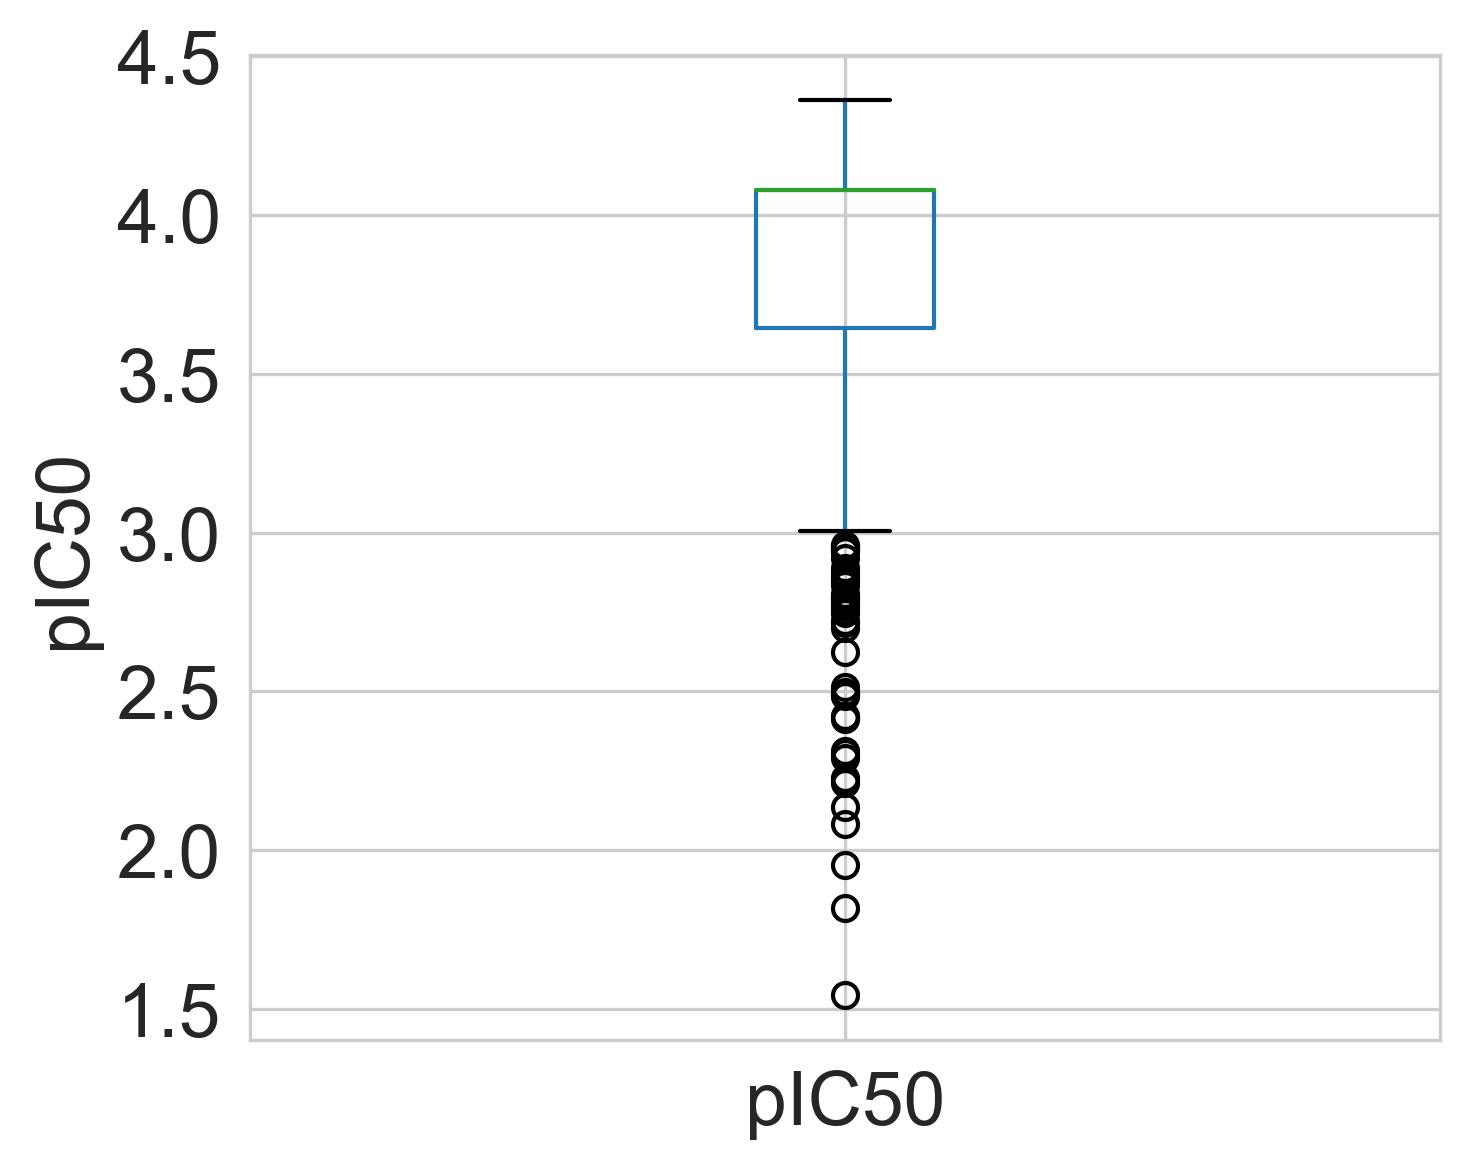

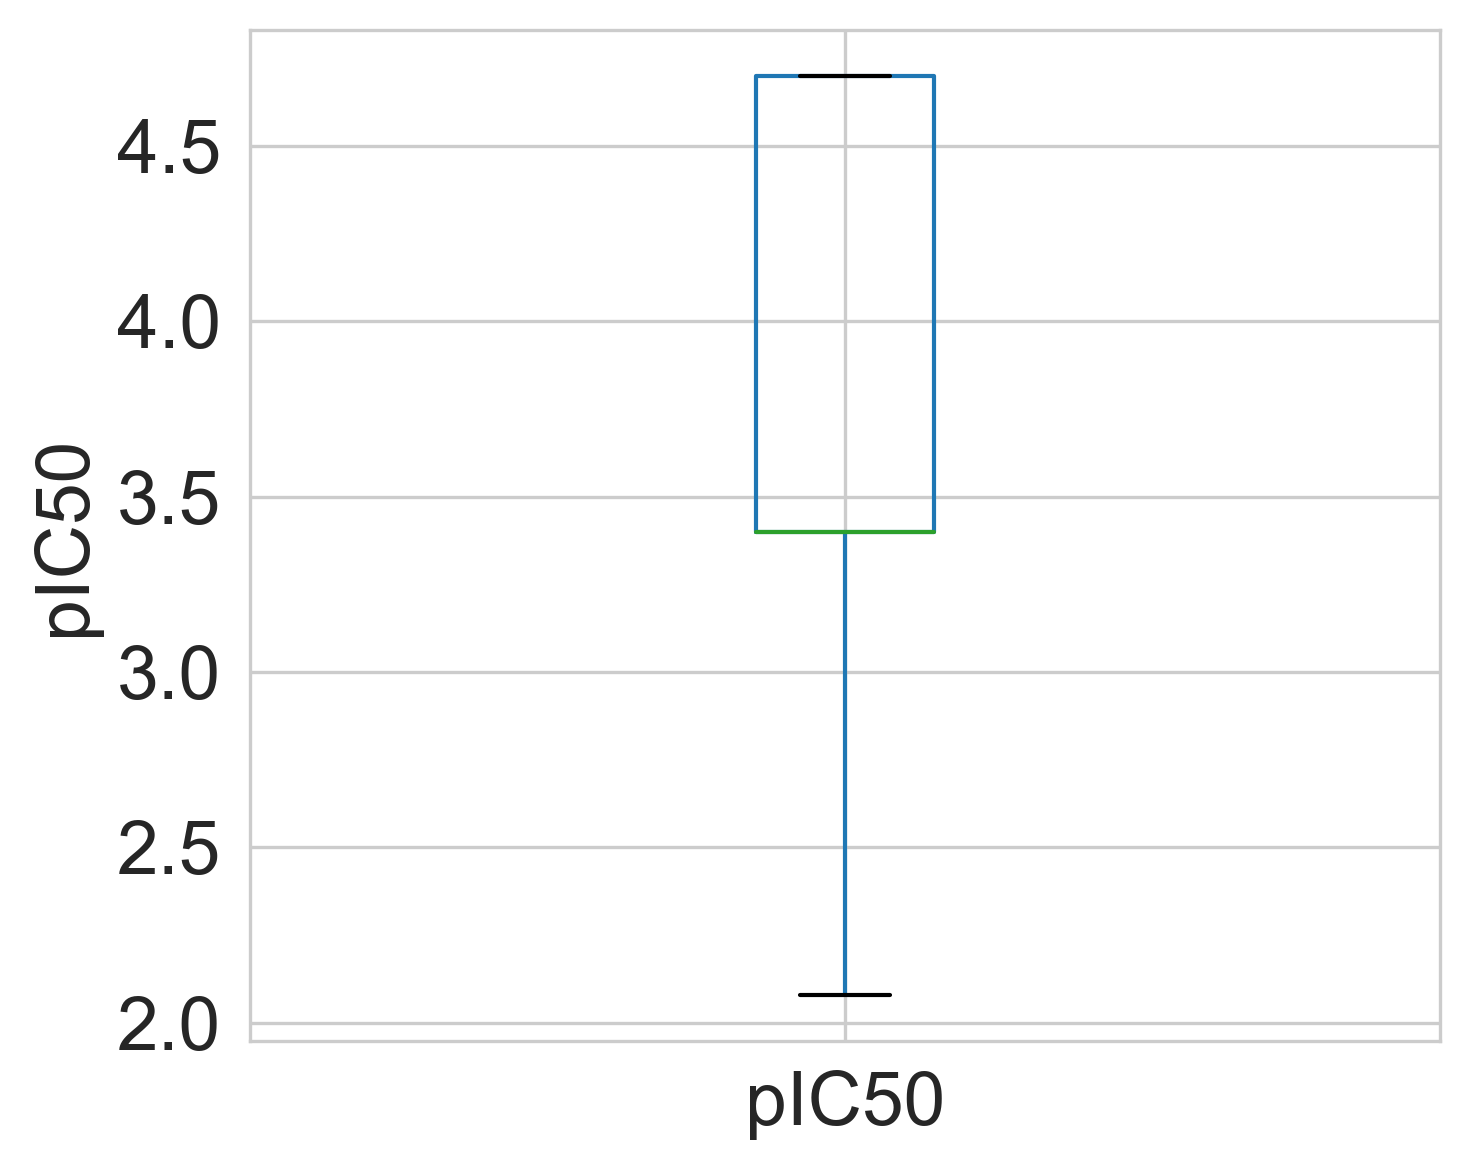

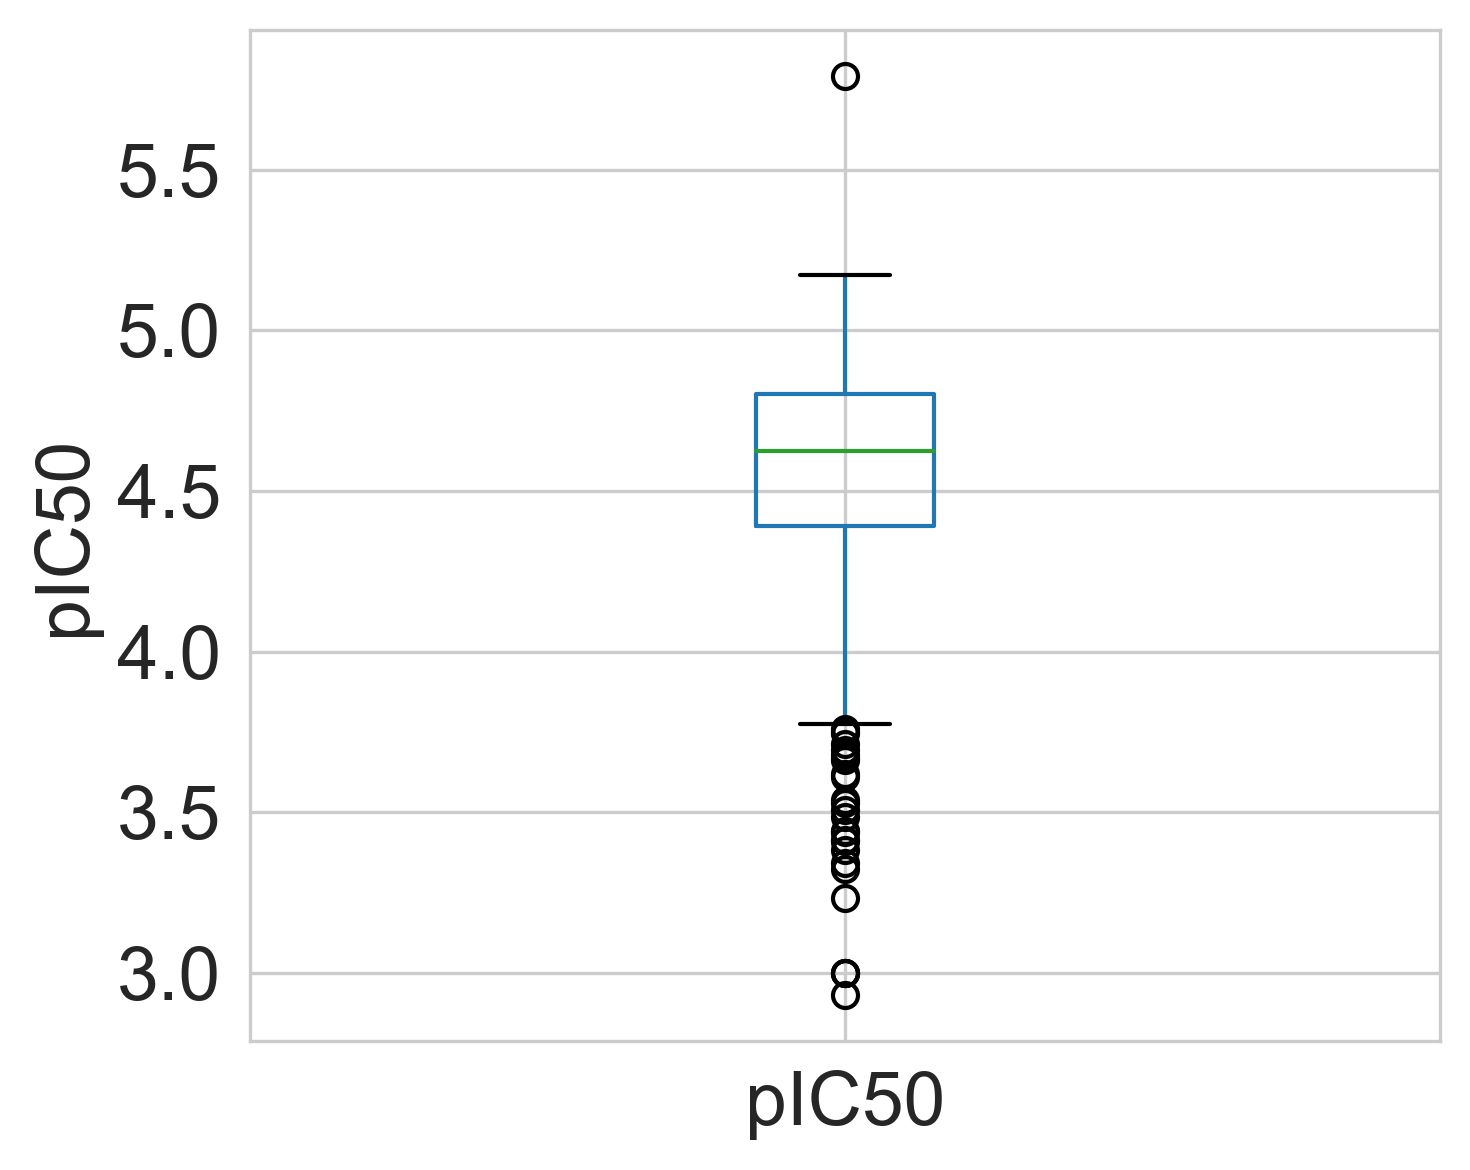

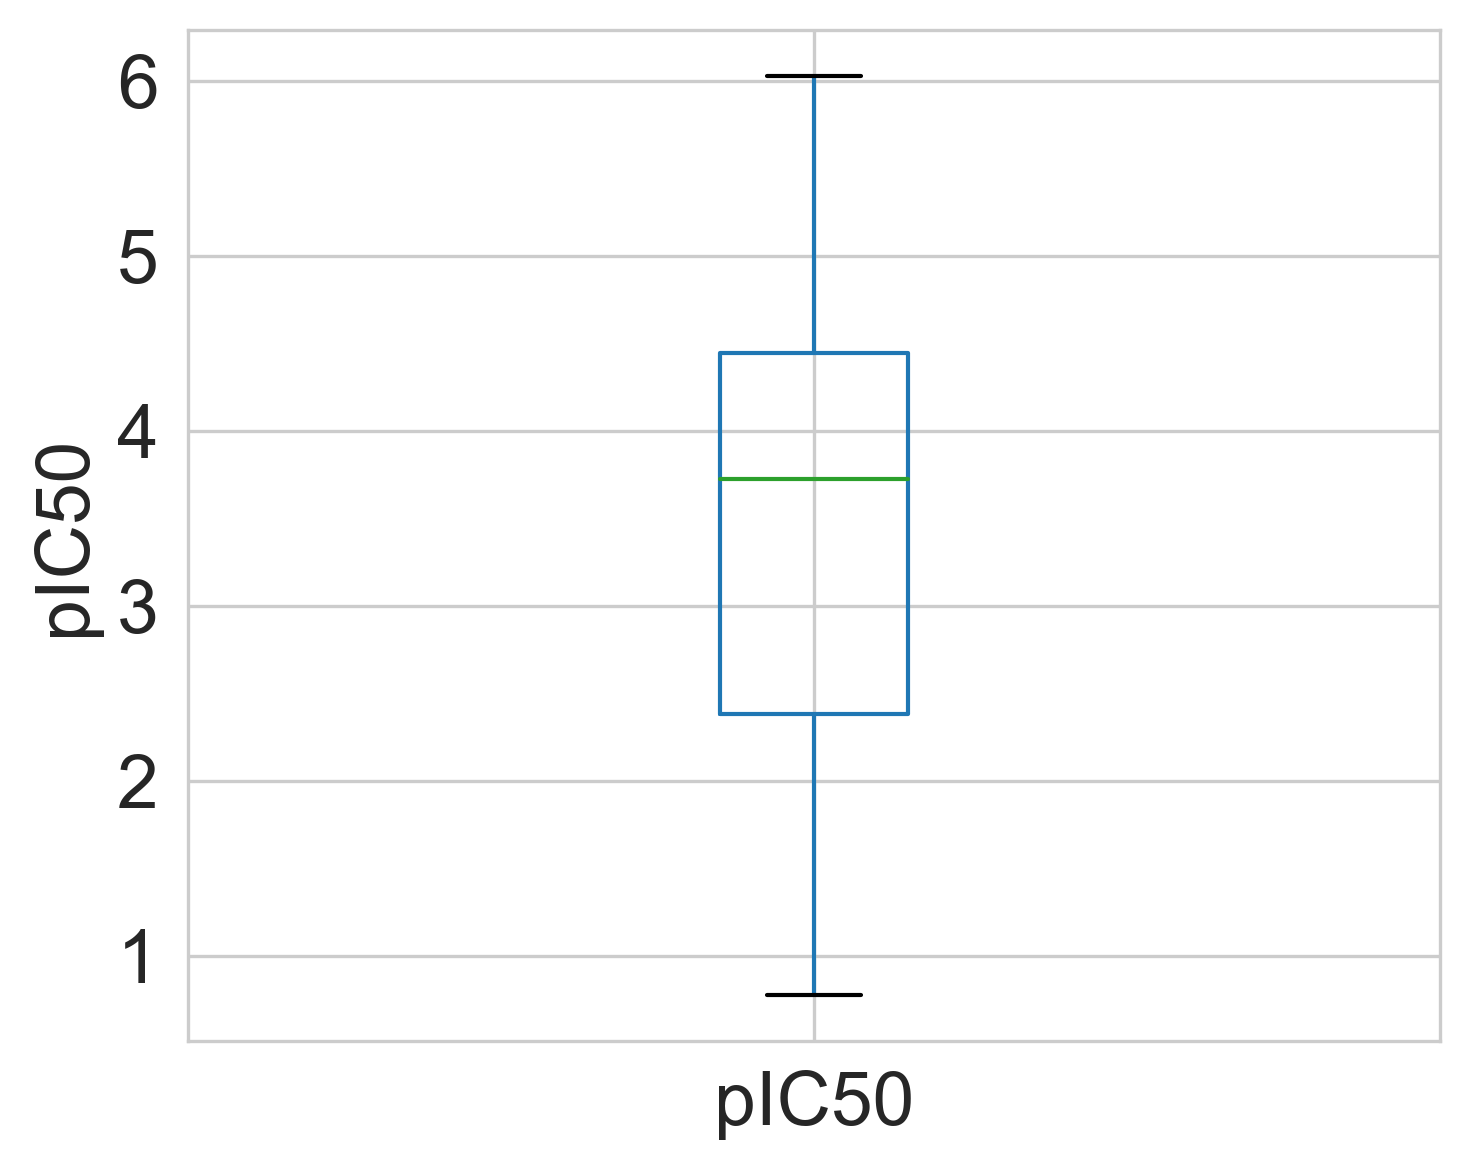

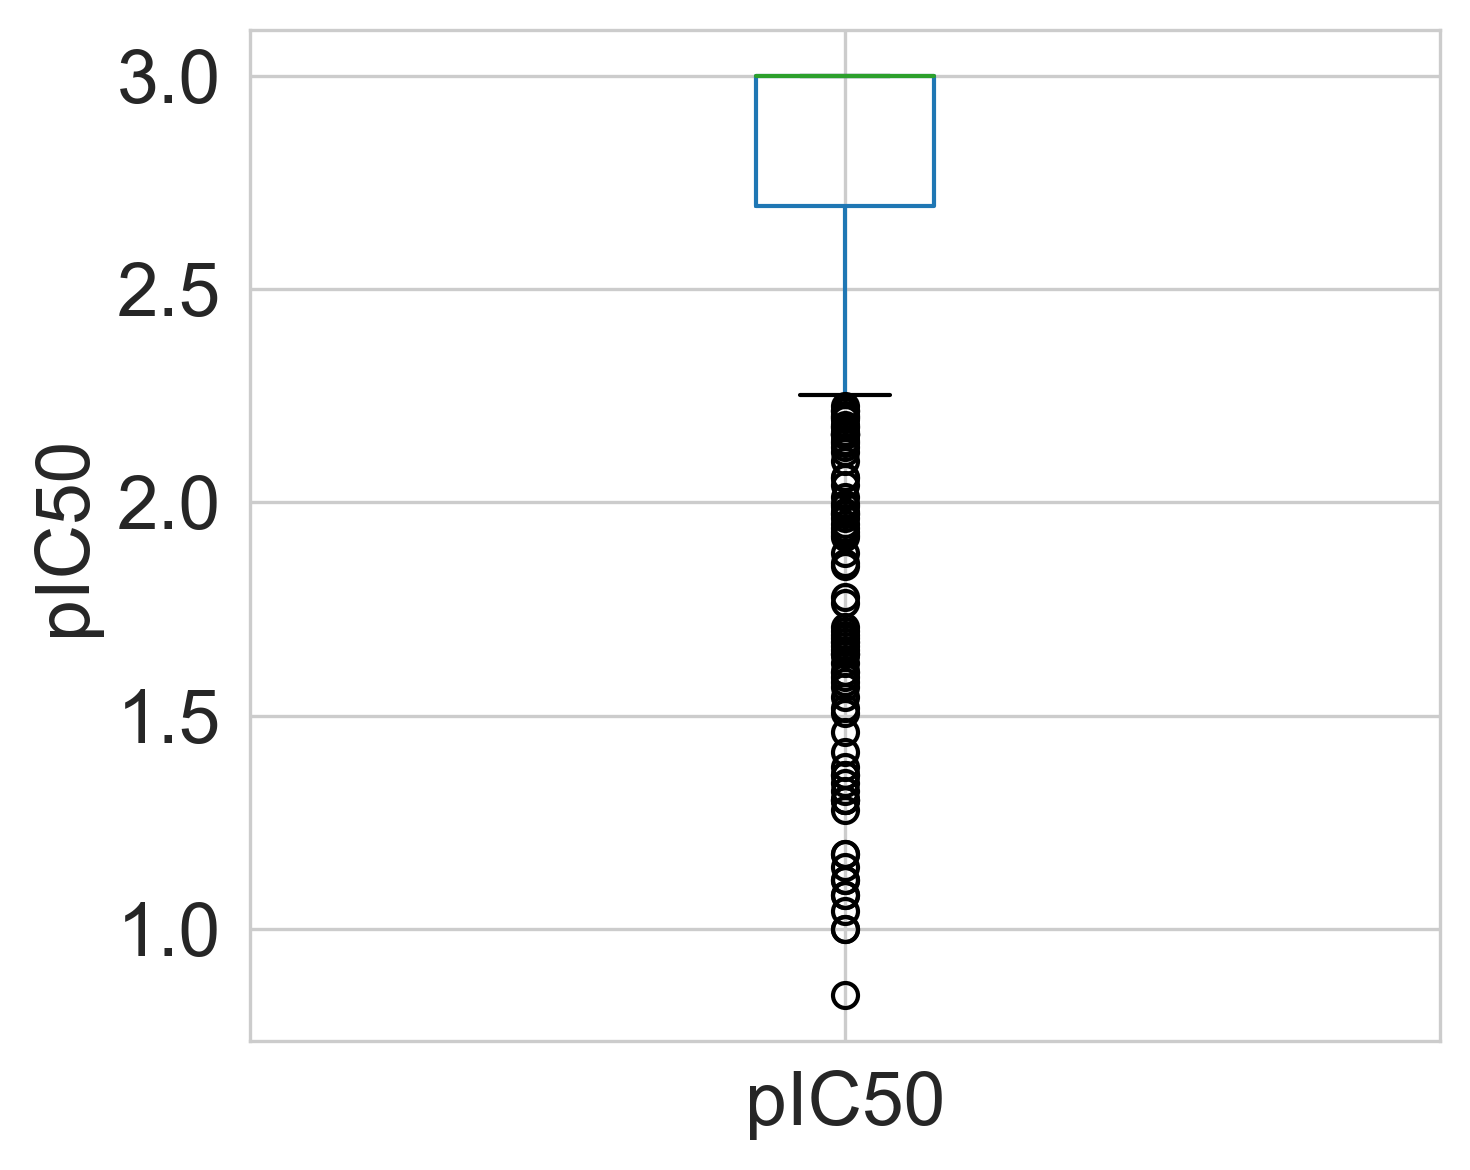

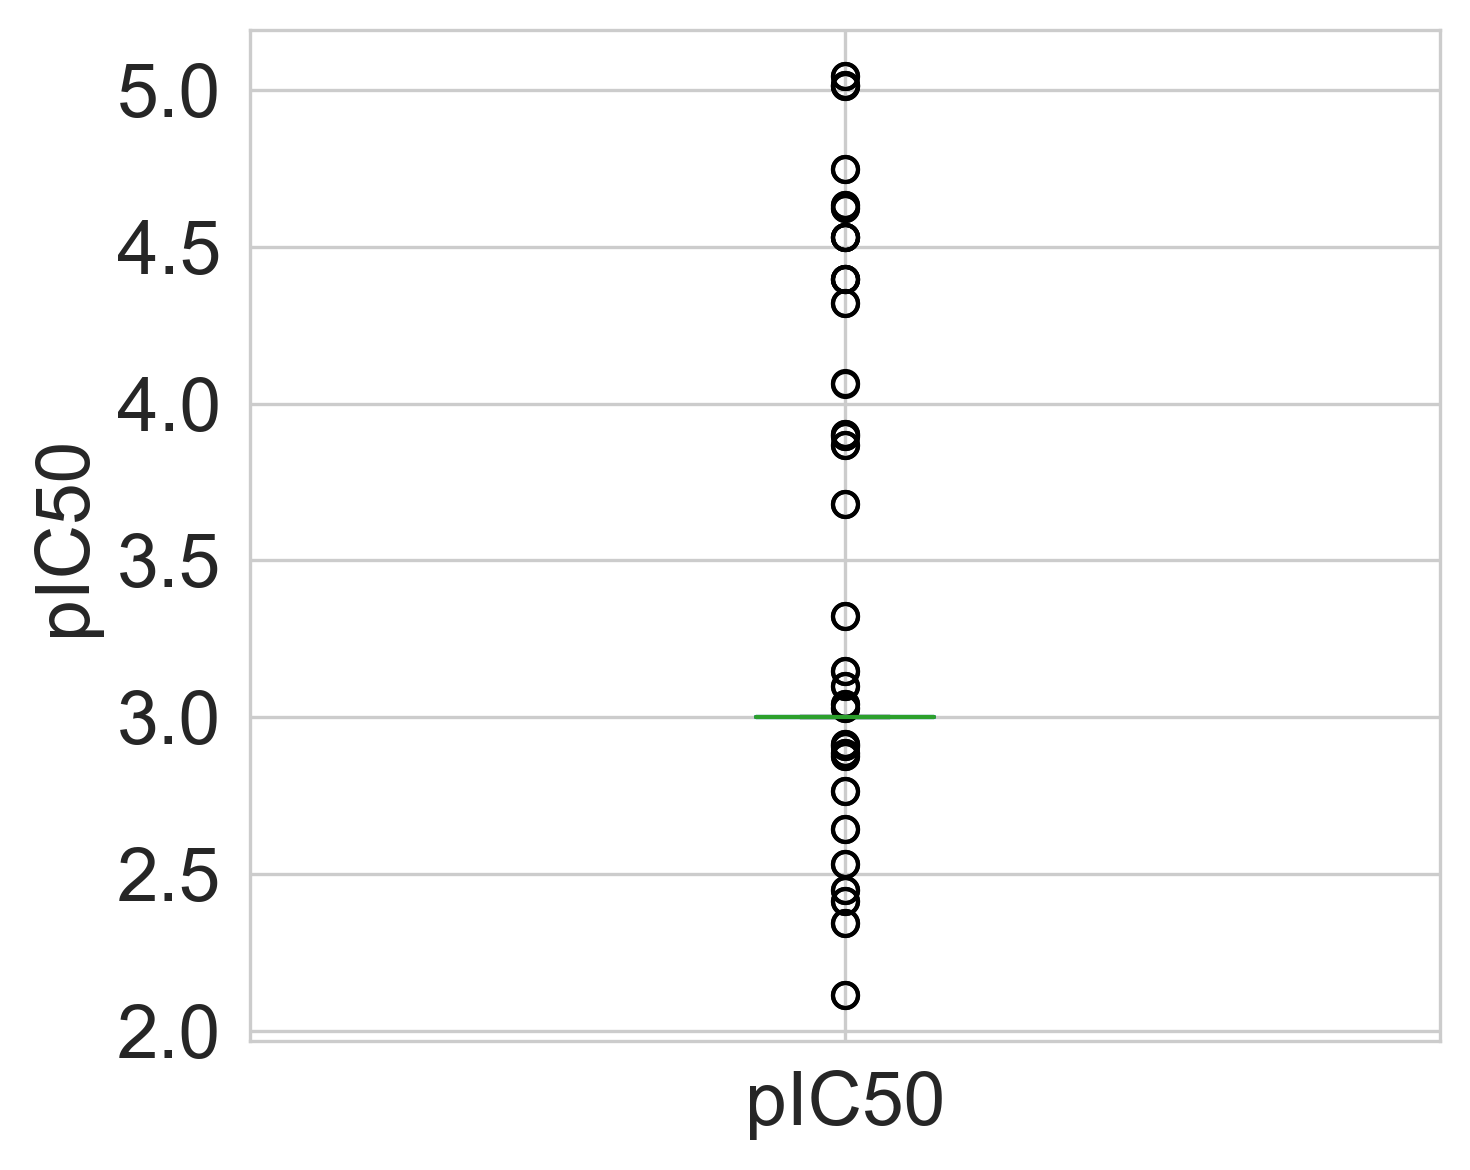

In [22]:
# Boxplots for top targets
for t in top_targets['Target Name'].tolist():
    sub = df[df['Target Name']==t]
    if len(sub) < 3:
        continue
    fig, ax = plt.subplots(figsize=(5,4))
    sub.boxplot(column='pIC50', ax=ax)
    #ax.set_title(f'log10(IC50) distribution\n{t} (n={len(sub)})')
    ax.set_ylabel('pIC50', fontsize=18)
    plt.xticks(fontsize=18, fontname='Arial')   
    plt.yticks(fontsize=18, fontname='Arial')
    plt.tight_layout()
    safe_name = t.replace('/','_').replace(' ','_')[:120]
    fig.savefig(OUTDIR / f'boxplot_log10IC50_{safe_name}.png', dpi=300)
    plt.show()

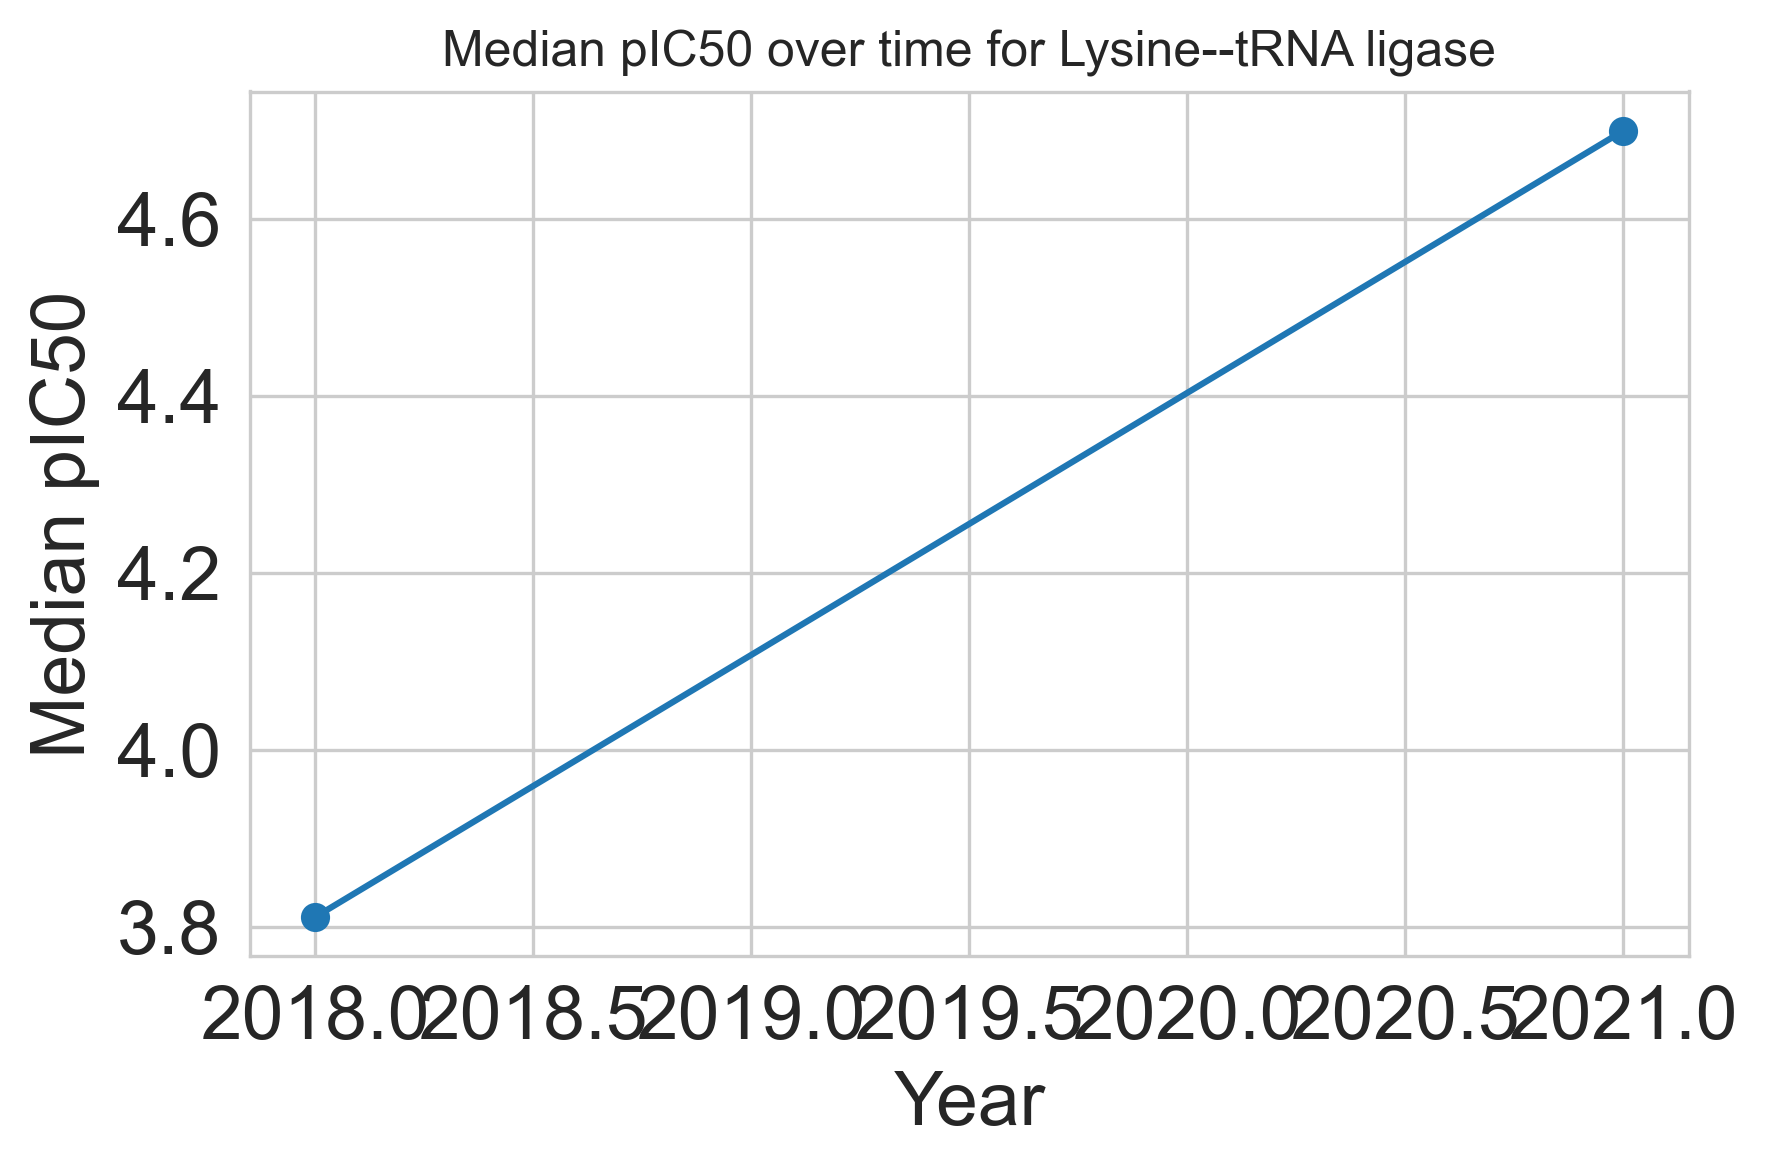

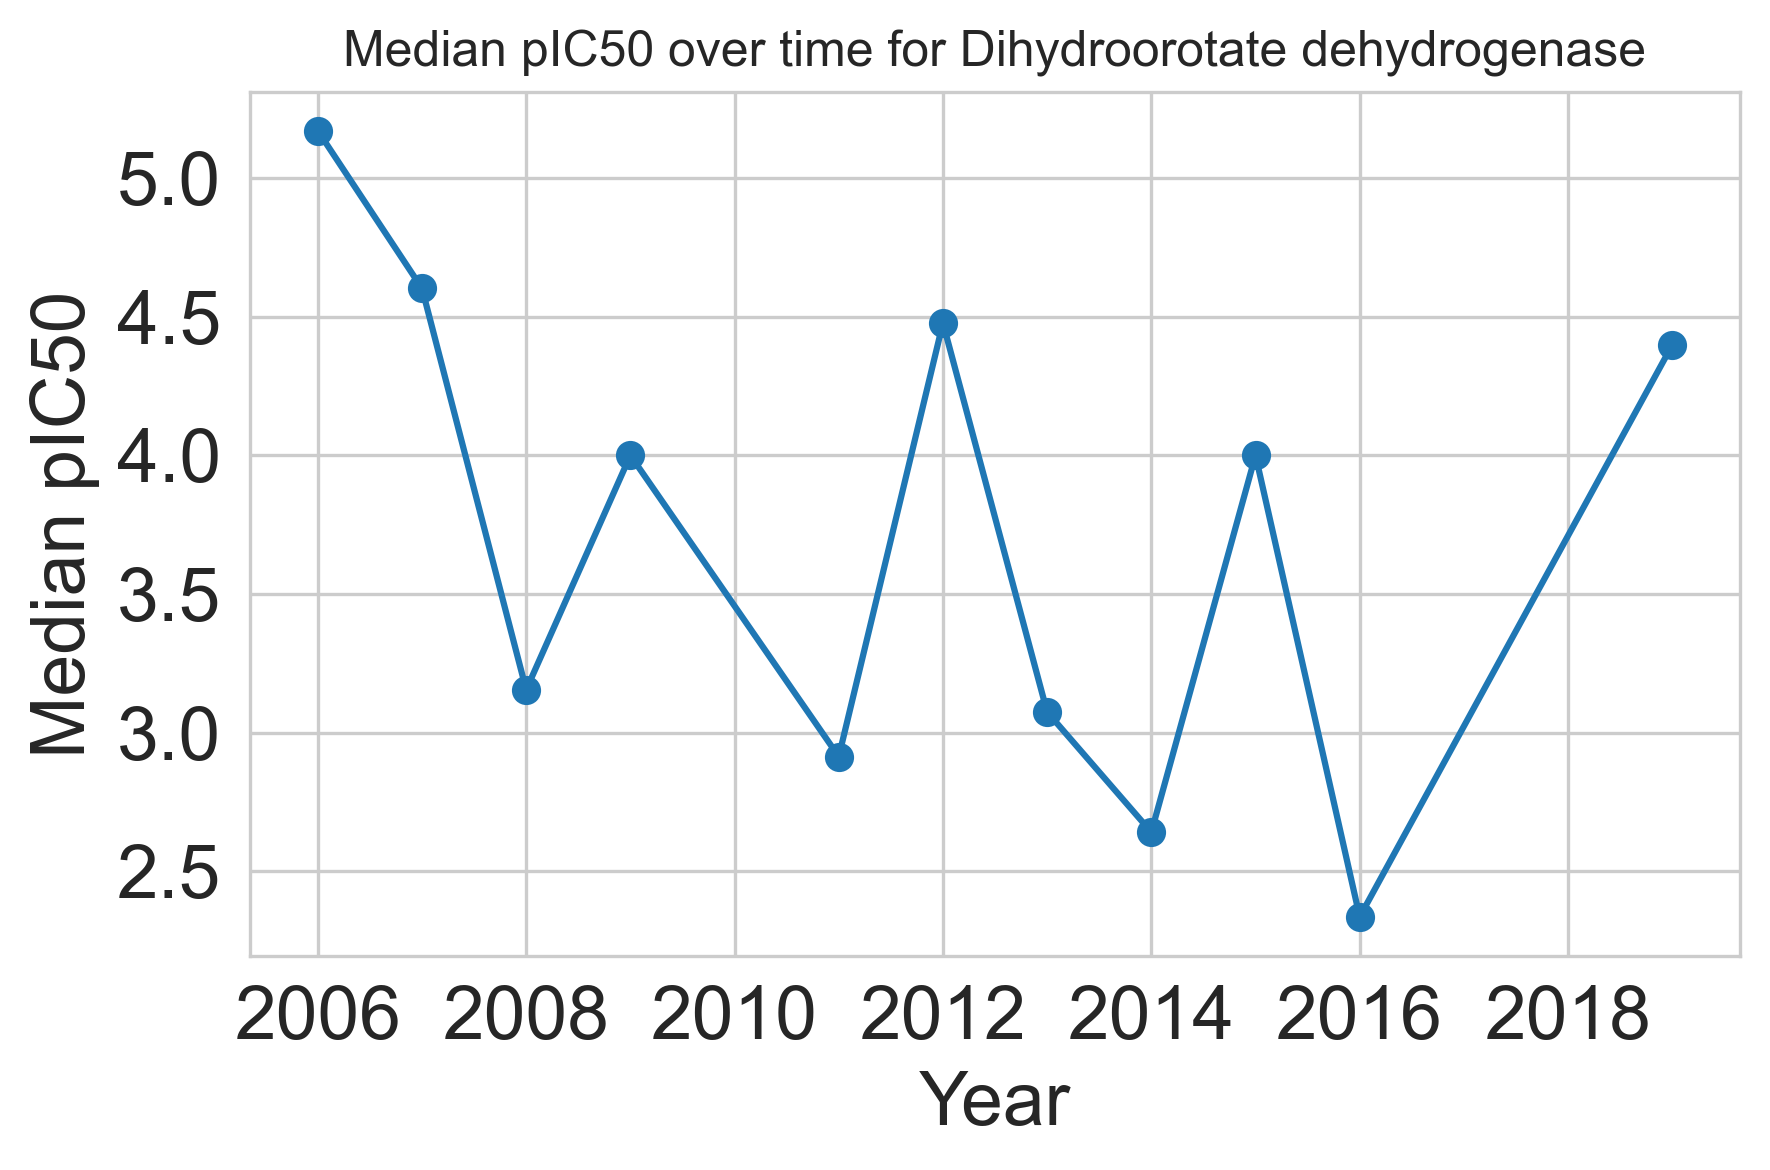

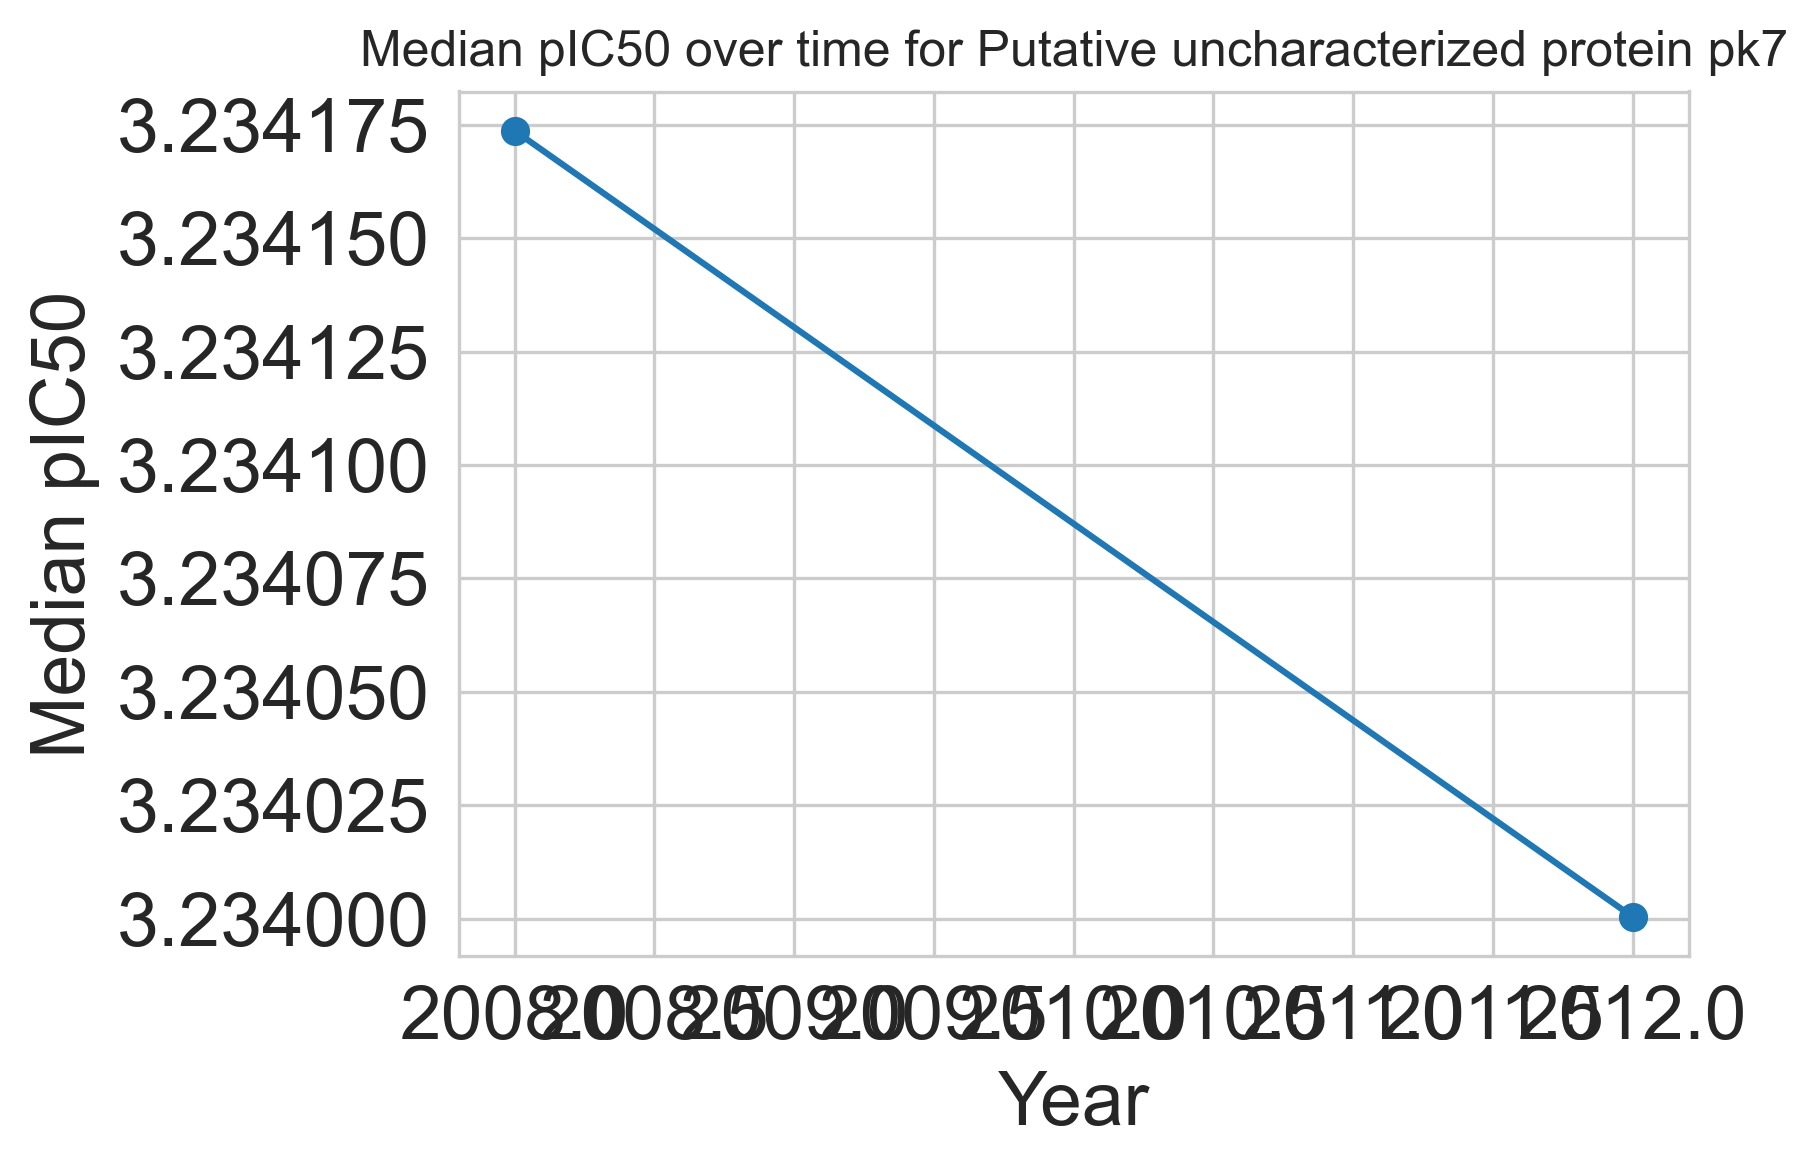

In [23]:
# Target-level time trends (for top targets if Year exists)

trend_files = []
if 'Year' in df.columns and not df_year.empty:
    for t in top_targets['Target Name'].tolist():
        sub = df[(df['Target Name']==t) & (df['Year'].notnull())].copy()
        if sub.empty:
            continue
        yearly_t = sub.groupby('Year').agg(median_log10IC50=('pIC50','median'), N=('IC50','size')).reset_index().sort_values('Year')
        if len(yearly_t) >= 2:
            fig, ax = plt.subplots(figsize=(6,4))
            ax.plot(yearly_t['Year'], yearly_t['median_log10IC50'], marker='o')
            ax.set_title(f'Median pIC50 over time for {t}')
            ax.set_xlabel('Year', fontsize=18)
            ax.set_ylabel('Median pIC50', fontsize=18)
            plt.xticks(fontsize=18, fontname='Arial')   # X-axis ticks
            plt.yticks(fontsize=18, fontname='Arial')
            plt.tight_layout()
            safe_name = t.replace('/','_').replace(' ','_')[:120]
            fpath = OUTDIR / f'trend_{safe_name}.png'
            fig.savefig(fpath, dpi=300)
            plt.show()
            trend_files.append(str(fpath))

In [24]:
# Statistical summaries 
# Save key summary stats and export small tables.


# Overall summary
summary = {
'N_total': len(df),
'N_targets': agg_target['Target Name'].nunique(),
'Top_targets': top_targets['Target Name'].tolist(),
}
pd.Series(summary).to_frame('value').to_csv(OUTDIR / 'overall_summary_publication1.csv')

In [25]:
# Export top targets
# Keep selected columns and round
top_targets[['Target Name','records','median_IC50','median_log10IC50','IQR_pIC50']].round(3).to_csv(OUTDIR / 'manuscript_table_top_targets.csv', index=False)

In [26]:
#Clustering Analysis
#Feature Selection and Scaling

cluster_df = df[["pIC50", "MW", "AlogP"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

In [27]:
#K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

cluster_df["Cluster"] = clusters
cluster_df.head()

,pIC50,MW,AlogP,Cluster
0,9.719331,268.75,3.30,2
1,4.324694,396.45,2.84,2
2,2.041393,396.45,2.84,1
3,2.880814,364.45,3.38,1
4,4.000000,254.24,2.87,2


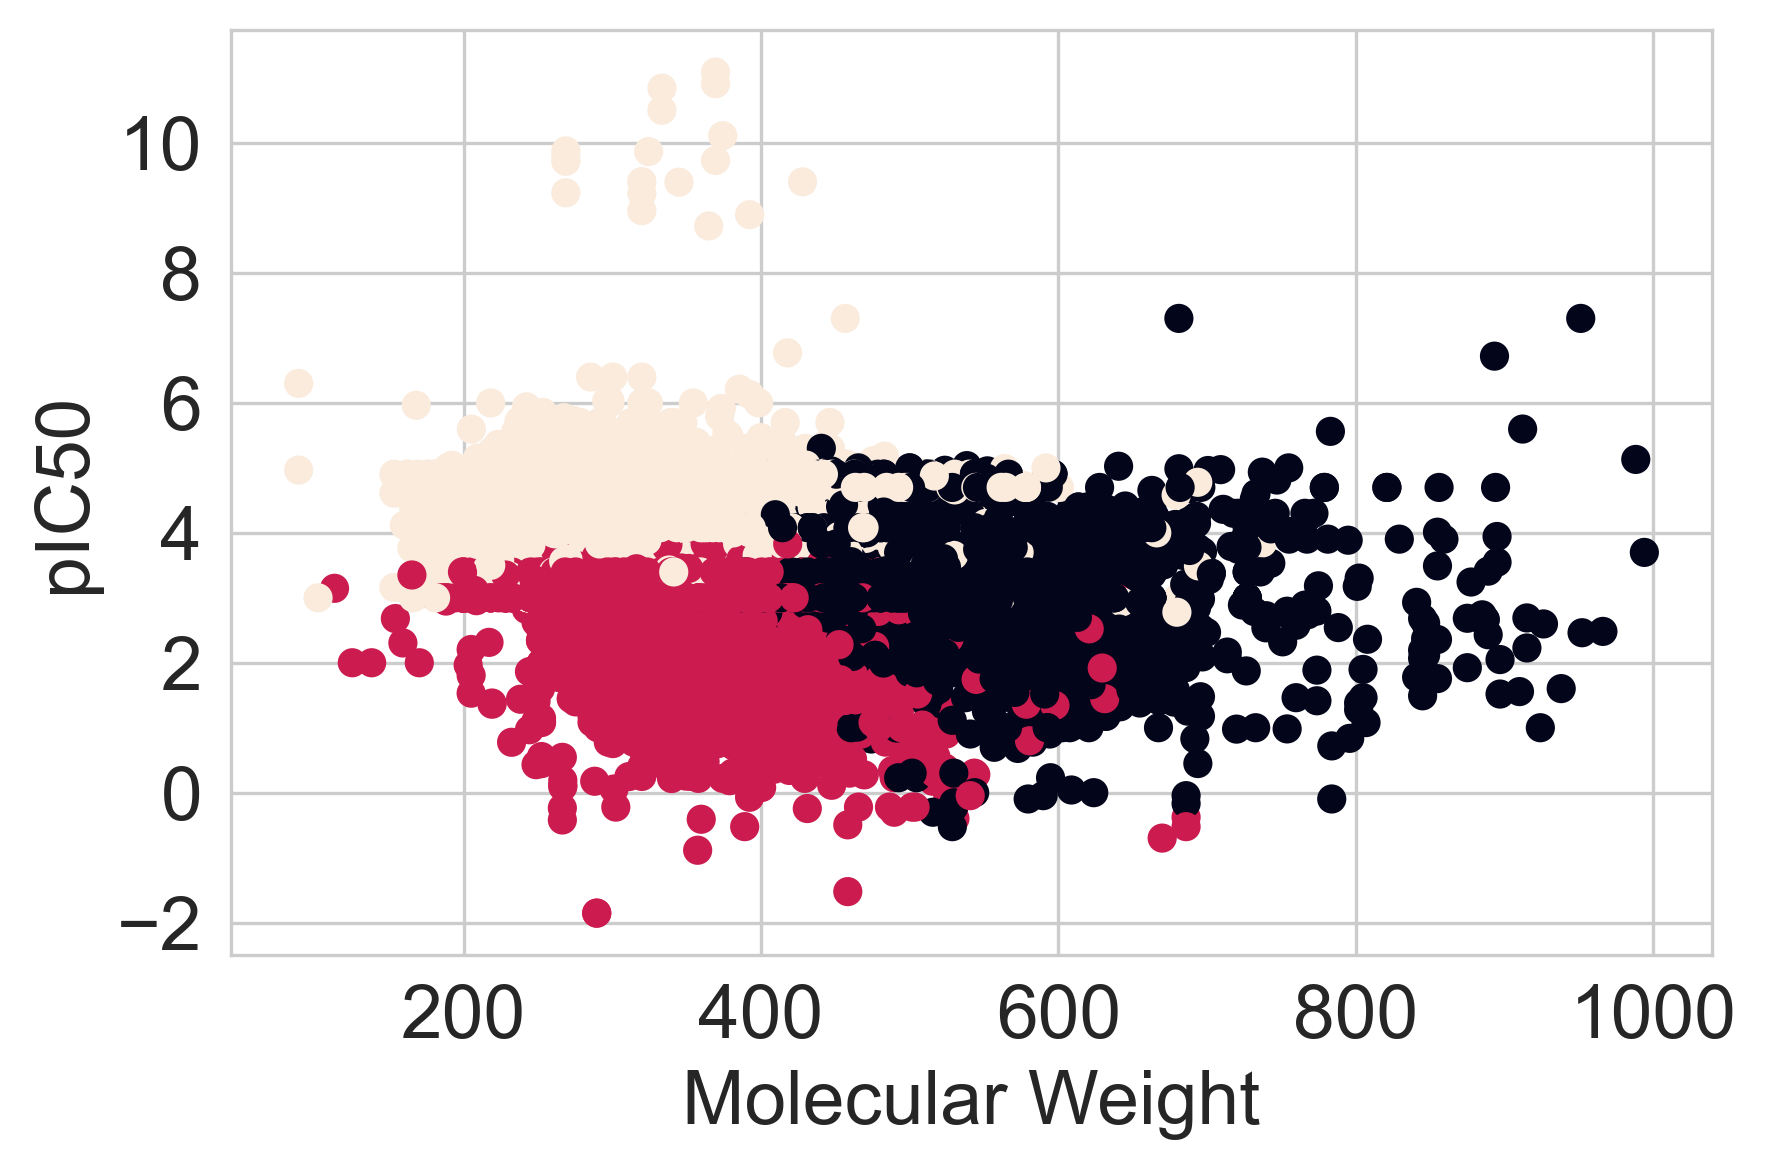

In [28]:
#Cluster Visualization

plt.figure(figsize=(6,4))
plt.scatter(
    cluster_df["MW"],
    cluster_df["pIC50"],
    c=cluster_df["Cluster"]
)
plt.xlabel("Molecular Weight", fontsize=18)
plt.ylabel("pIC50", fontsize=18)
plt.xticks(fontsize=18, fontname='Arial')   # X-axis ticks
plt.yticks(fontsize=18, fontname='Arial')
#plt.title("K-Means Clustering of Antimalarial Compounds")
plt.tight_layout()
plt.savefig(OUTDIR/"kmeans_clusters.png")
plt.show()

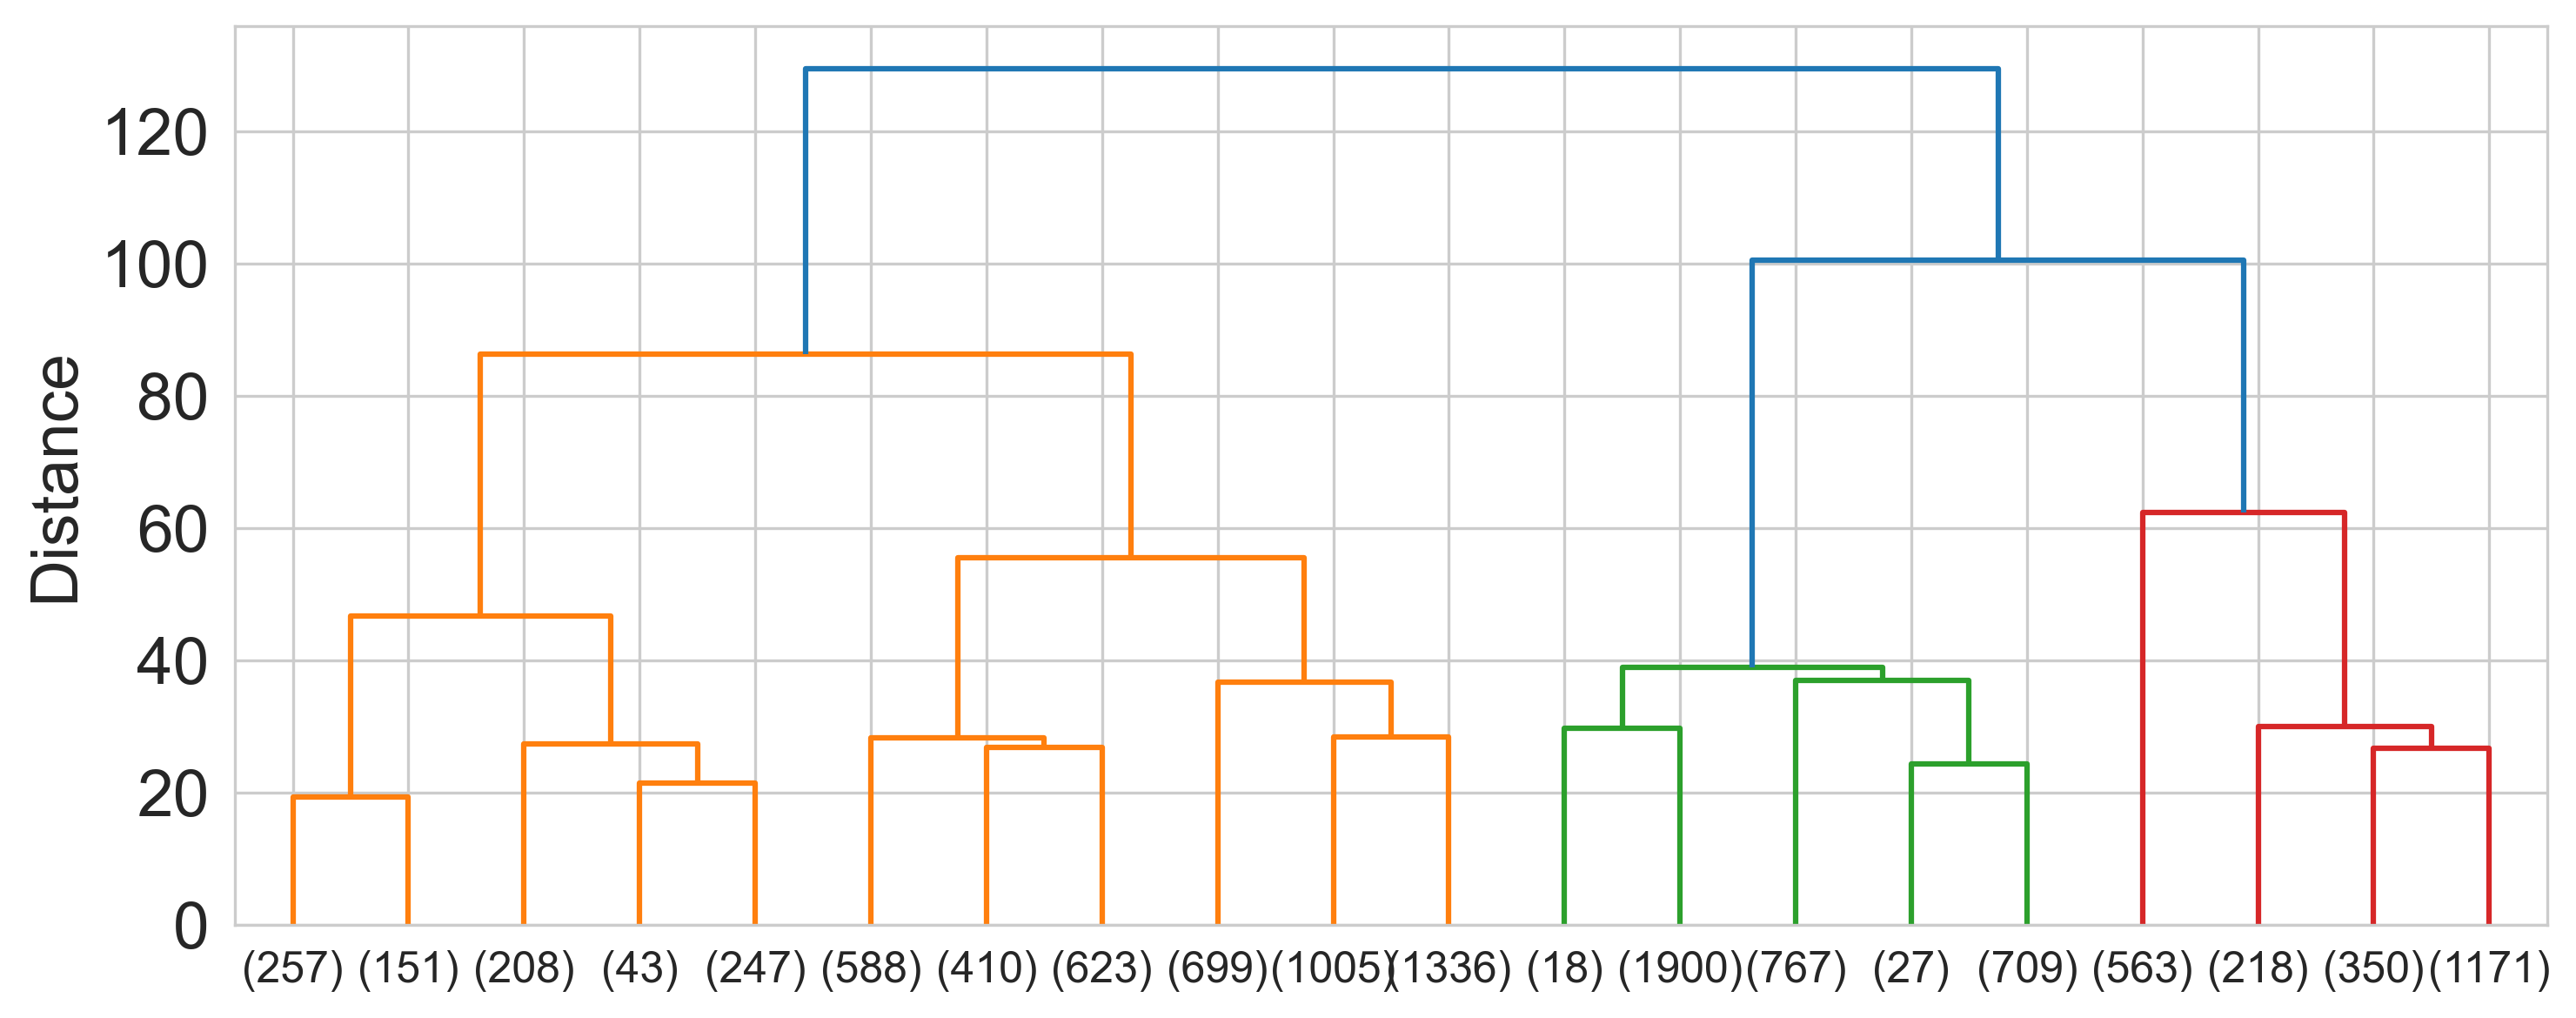

In [29]:
#Hierarchical Clustering

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode="lastp", p=20)
#plt.title("Hierarchical Clustering Dendrogram")
plt.ylabel("Distance", fontsize=18)
#plt.xticks(fontsize=18, fontname='Arial')   # X-axis ticks
plt.yticks(fontsize=18, fontname='Arial')
plt.tight_layout()
plt.savefig(OUTDIR/"hierarchical_dendrogram.png")
plt.show()

In [ ]:
### Key Findings
- Median IC50 shows a statistically significant temporal trend (linear regression and Mann–Kendall).
- Potency differs substantially across biological targets.
- Clustering reveals distinct compound groups with shared potency and physicochemical profiles.
- Results support data-driven target prioritization in antimalarial drug discovery.

In [31]:
# Normality Test (Shapiro-Wilk)
from scipy.stats import shapiro

stat, p = shapiro(df["pIC50"])
print(f"Shapiro-Wilk Test p-value: {p:.4e}")

if p < 0.05:
    print("Data is not normally distributed → Use non-parametric tests")
else:
    print("Data is normally distributed → Parametric tests applicable")

Shapiro-Wilk Test p-value: 0.0000e+00
Data is not normally distributed → Use non-parametric tests


In [32]:
# Kruskal-Wallis Test + Effect Size
from scipy.stats import kruskal
import numpy as np

groups = [group["pIC50"].values for name, group in df.groupby("Target Name")]

H, p = kruskal(*groups)

n = len(df)
k = len(groups)
eta_squared = (H - k + 1) / (n - k)

print(f"Kruskal-Wallis H = {H:.3f}, p = {p:.3e}")
print(f"Effect size (eta squared) = {eta_squared:.3f}")

Kruskal-Wallis H = 6092.262, p = 0.000e+00
Effect size (eta squared) = 0.536


In [33]:
# Dunn’s Post-hoc Test
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(df, val_col='pIC50', group_col='Target Name', p_adjust='bonferroni')
print(dunn)

                                                    1-deoxy-D-xylulose 5-phosphate reductoisomerase, apicoplastic  \
1-deoxy-D-xylulose 5-phosphate reductoisomerase...                                           1.000000               
3-oxoacyl-(Acyl-carrier protein) reductase                                                   0.000027               
3-oxoacyl-acyl-carrier protein reductase                                                     1.000000               
Adenosylhomocysteinase                                                                       1.000000               
Apical membrane antigen 1                                                                    1.000000               
...                                                                                               ...               
Spermidine synthase                                                                          1.000000               
Subtilisin-like protease                                        

In [38]:
# Cluster Validation (Silhouette Score)
from sklearn.metrics import silhouette_score

X = cluster_df[["MW", "AlogP", "pIC50"]]
labels = cluster_df["Cluster"]

score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.050


In [39]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_scaled, clusters)
print(f"Davies-Bouldin Score: {db_score:.3f}")

Davies-Bouldin Score: 1.178


In [36]:
# Multivariate Regression Analysis
import statsmodels.api as sm

X = df[["MW", "AlogP"]].dropna()
y = df.loc[X.index, "pIC50"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  pIC50   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     389.1
Date:                Sat, 02 May 2026   Prob (F-statistic):          3.85e-164
Time:                        09:34:30   Log-Likelihood:                -16282.
No. Observations:               11290   AIC:                         3.257e+04
Df Residuals:                   11287   BIC:                         3.259e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5537      0.037    123.373      0.0

In [37]:
# Levene’s Test for Equality of Variances
from scipy.stats import levene

groups = [group["pIC50"].values for name, group in df.groupby("Target Name")]

stat, p = levene(*groups)
print(f"Levene’s test p-value: {p:.3e}")

Levene’s test p-value: 0.000e+00
